In [1]:
import sys 
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


In [ ]:
root_dir = Path.cwd().parent
sys.path.append(str(root_dir))

In [55]:
from src.data_loader import load_data_tidy
from src.eda_utils import display_summary_statistics, calculate_skewness, calculate_kurtosis, plot_histogram, plot_boxplot, plot_bivariate_num_target, plot_bivariate_cat_target, perform_chi_square_test, plot_delay_rate, plot_correlation_heatmap
from src.cleaning_process import check_columns_name, export_data

In [4]:
df_4_6 = load_data_tidy("tidy_dataset_4_6")
df_7_9 = load_data_tidy("tidy_dataset_7_9")

In [5]:
print(df_4_6.head())


   Order date  CLASSIFY_CD  CUST_CD BRAND_CD     INNER_CD SUPPLIER_CD  \
0  2022-04-04     21034701       74     HAK1  F7371210001        8107   
1  2022-04-26     23028764     4180     S3M1  K9045010089        8484   
2  2022-04-19     21059031       74     THT1  F5109250104        8233   
3  2022-04-22      3731227       74     MSM1  79014275005        3013   
4  2022-04-22      3954111       74     MSM1  30357450001        3081   

   Sales order line number  Stock class  Consider count hodiday Saturday  \
0                        1            1                                4   
1                        1            1                                1   
2                        1            1                                4   
3                        1            1                                0   
4                        1            1                                0   

   SO QTY  ...  HEAVY_FLG  EXPENSIVE_FLG SPECIAL_DIV SPECIFY_PRODUCTION_DAYS  \
0       1  ...          

In [6]:
print(df_7_9.head())

   Order date  CLASSIFY_CD  CUST_CD BRAND_CD     INNER_CD SUPPLIER_CD  \
0  2022-08-25     21031103   344472     OSA1  F7171260007        8121   
1  2022-08-12      3712333      641     MSM1  30071630003        0263   
2  2022-07-08     21045918    32167     SMC1  F7499483132        9102   
3  2022-07-08     21058302   710046     MIB1  F4524160001        9163   
4  2022-08-25     21050569   107539     NIQ1  F3017310155        9176   

   Sales order line number  Stock class  Consider count hodiday Saturday  \
0                        8            1                                4   
1                        1            1                                0   
2                        1            1                                4   
3                        1            1                                4   
4                        6            1                                4   

   SO QTY  ...  label  Ship Mode SHIP DECISION NO PACK QTY  WEIGHT PER PIECE  \
0       1  ...      1   

In [7]:
df_4_6['Order date'] = pd.to_datetime(df_4_6['Order date'], errors='coerce')
df_7_9['Order date'] = pd.to_datetime(df_7_9['Order date'], errors='coerce')
df_4_6['VSD'] = pd.to_datetime(df_4_6['VSD'], errors='coerce')
df_7_9['VSD'] = pd.to_datetime(df_7_9['VSD'], errors='coerce')

### ANALYZE UNIVARIATE FOR DATASET APRIL TO JUNE

In [8]:
df_4_6.shape

(399053, 37)

In [9]:
df_4_6.dtypes

Order date                         datetime64[ns]
CLASSIFY_CD                                 int64
CUST_CD                                     int64
BRAND_CD                                   object
INNER_CD                                   object
SUPPLIER_CD                                object
Sales order line number                     int64
Stock class                                 int64
Consider count hodiday Saturday             int64
SO QTY                                      int64
ALLOCATION QTY                              int64
SUPPLIER INV AMOUNT                       float64
PACKING RANK                               object
PRODUCT_CD                                 object
PRODUCT ATTRIBUTION                         int64
SPECIAL DIV                                 int64
LOGICAL PLANT                               int64
PURCHASE AMOUNT                           float64
VSD                                datetime64[ns]
DIRECT SHIP FLG                             int64


In [10]:
target_col = ['label']
date_cols = ['Order date', 'VSD']

In [11]:

num_cols_4_6 = ['Sales order line number',
                'SO QTY',
                'ALLOCATION QTY',
                'SUPPLIER INV AMOUNT',
                'PURCHASE AMOUNT',
                'SHIP DECISION NO',
                'PACK QTY',
                'WEIGHT PER PIECE',
                'SO_DAY_OF_MONTH',
                'SPECIFY_PRODUCTION_DAYS',
                'SPECIFY_SHIP_DAYS',
                'SO_TIME'
]
cat_cols_4_6 = df_4_6.columns.difference(num_cols_4_6).difference(target_col).difference(date_cols).tolist()

In [12]:
# Display summary statistics for numerical columns
display_summary_statistics(df_4_6, num_cols_4_6)

,Sales order line number,SO QTY,ALLOCATION QTY,SUPPLIER INV AMOUNT,PURCHASE AMOUNT,SHIP DECISION NO,PACK QTY,WEIGHT PER PIECE,SO_DAY_OF_MONTH,SPECIFY_PRODUCTION_DAYS,SPECIFY_SHIP_DAYS,SO_TIME
count,399053.000000,399053.000000,399053.000000,3.990530e+05,3.990530e+05,365736.000000,399053.000000,3.990530e+05,399053.000000,399053.000000,399053.000000,399053.000000
mean,107.772597,6.383099,6.383099,5.123816e+03,5.124879e+03,326041.578513,2.906391,8.496466e+02,16.026816,-0.973059,-0.954046,135193.173295
std,2853.767465,95.126978,95.126978,2.070139e+04,2.070179e+04,183577.610025,114.741591,6.727219e+03,8.398729,1.192083,1.428838,30811.081333
min,1.000000,1.000000,1.000000,9.000000e-01,0.000000e+00,142.000000,0.000000,1.000000e+00,1.000000,-1.000000,-1.000000,73000.000000
25%,1.000000,1.000000,1.000000,6.700000e+02,6.700000e+02,192088.750000,0.000000,1.700000e+01,9.000000,-1.000000,-1.000000,110138.000000
50%,3.000000,2.000000,2.000000,1.640000e+03,1.640000e+03,286632.500000,0.000000,1.000000e+02,16.000000,-1.000000,-1.000000,140019.000000
75%,12.000000,4.000000,4.000000,4.172000e+03,4.174000e+03,410034.500000,0.000000,4.670000e+02,23.000000,-1.000000,-1.000000,161911.000000
max,90025.000000,40000.000000,40000.000000,4.153000e+06,4.153000e+06,999495.000000,18000.000000,1.007995e+06,31.000000,300.000000,199.000000,202951.000000


In [13]:
# Calculate skewness for numerical columns
calculate_skewness(df_4_6, num_cols_4_6)

Sales order line number     31.415341
SO QTY                     255.022457
ALLOCATION QTY             255.022457
SUPPLIER INV AMOUNT         51.843249
PURCHASE AMOUNT             51.840178
SHIP DECISION NO             1.012129
PACK QTY                    91.134765
WEIGHT PER PIECE            83.893646
SO_DAY_OF_MONTH             -0.028911
SPECIFY_PRODUCTION_DAYS    117.180058
SPECIFY_SHIP_DAYS           64.957375
SO_TIME                     -0.055461
dtype: float64

In [14]:
# Calculate kurtosis for numerical columns
calculate_kurtosis(df_4_6, num_cols_4_6)

Sales order line number      986.444006
SO QTY                     90140.114029
ALLOCATION QTY             90140.114029
SUPPLIER INV AMOUNT         6301.140034
PURCHASE AMOUNT             6300.643837
SHIP DECISION NO               0.646613
PACK QTY                   10235.528540
WEIGHT PER PIECE           10496.440874
SO_DAY_OF_MONTH               -1.078282
SPECIFY_PRODUCTION_DAYS    21033.715267
SPECIFY_SHIP_DAYS           5851.751574
SO_TIME                       -1.120699
dtype: float64

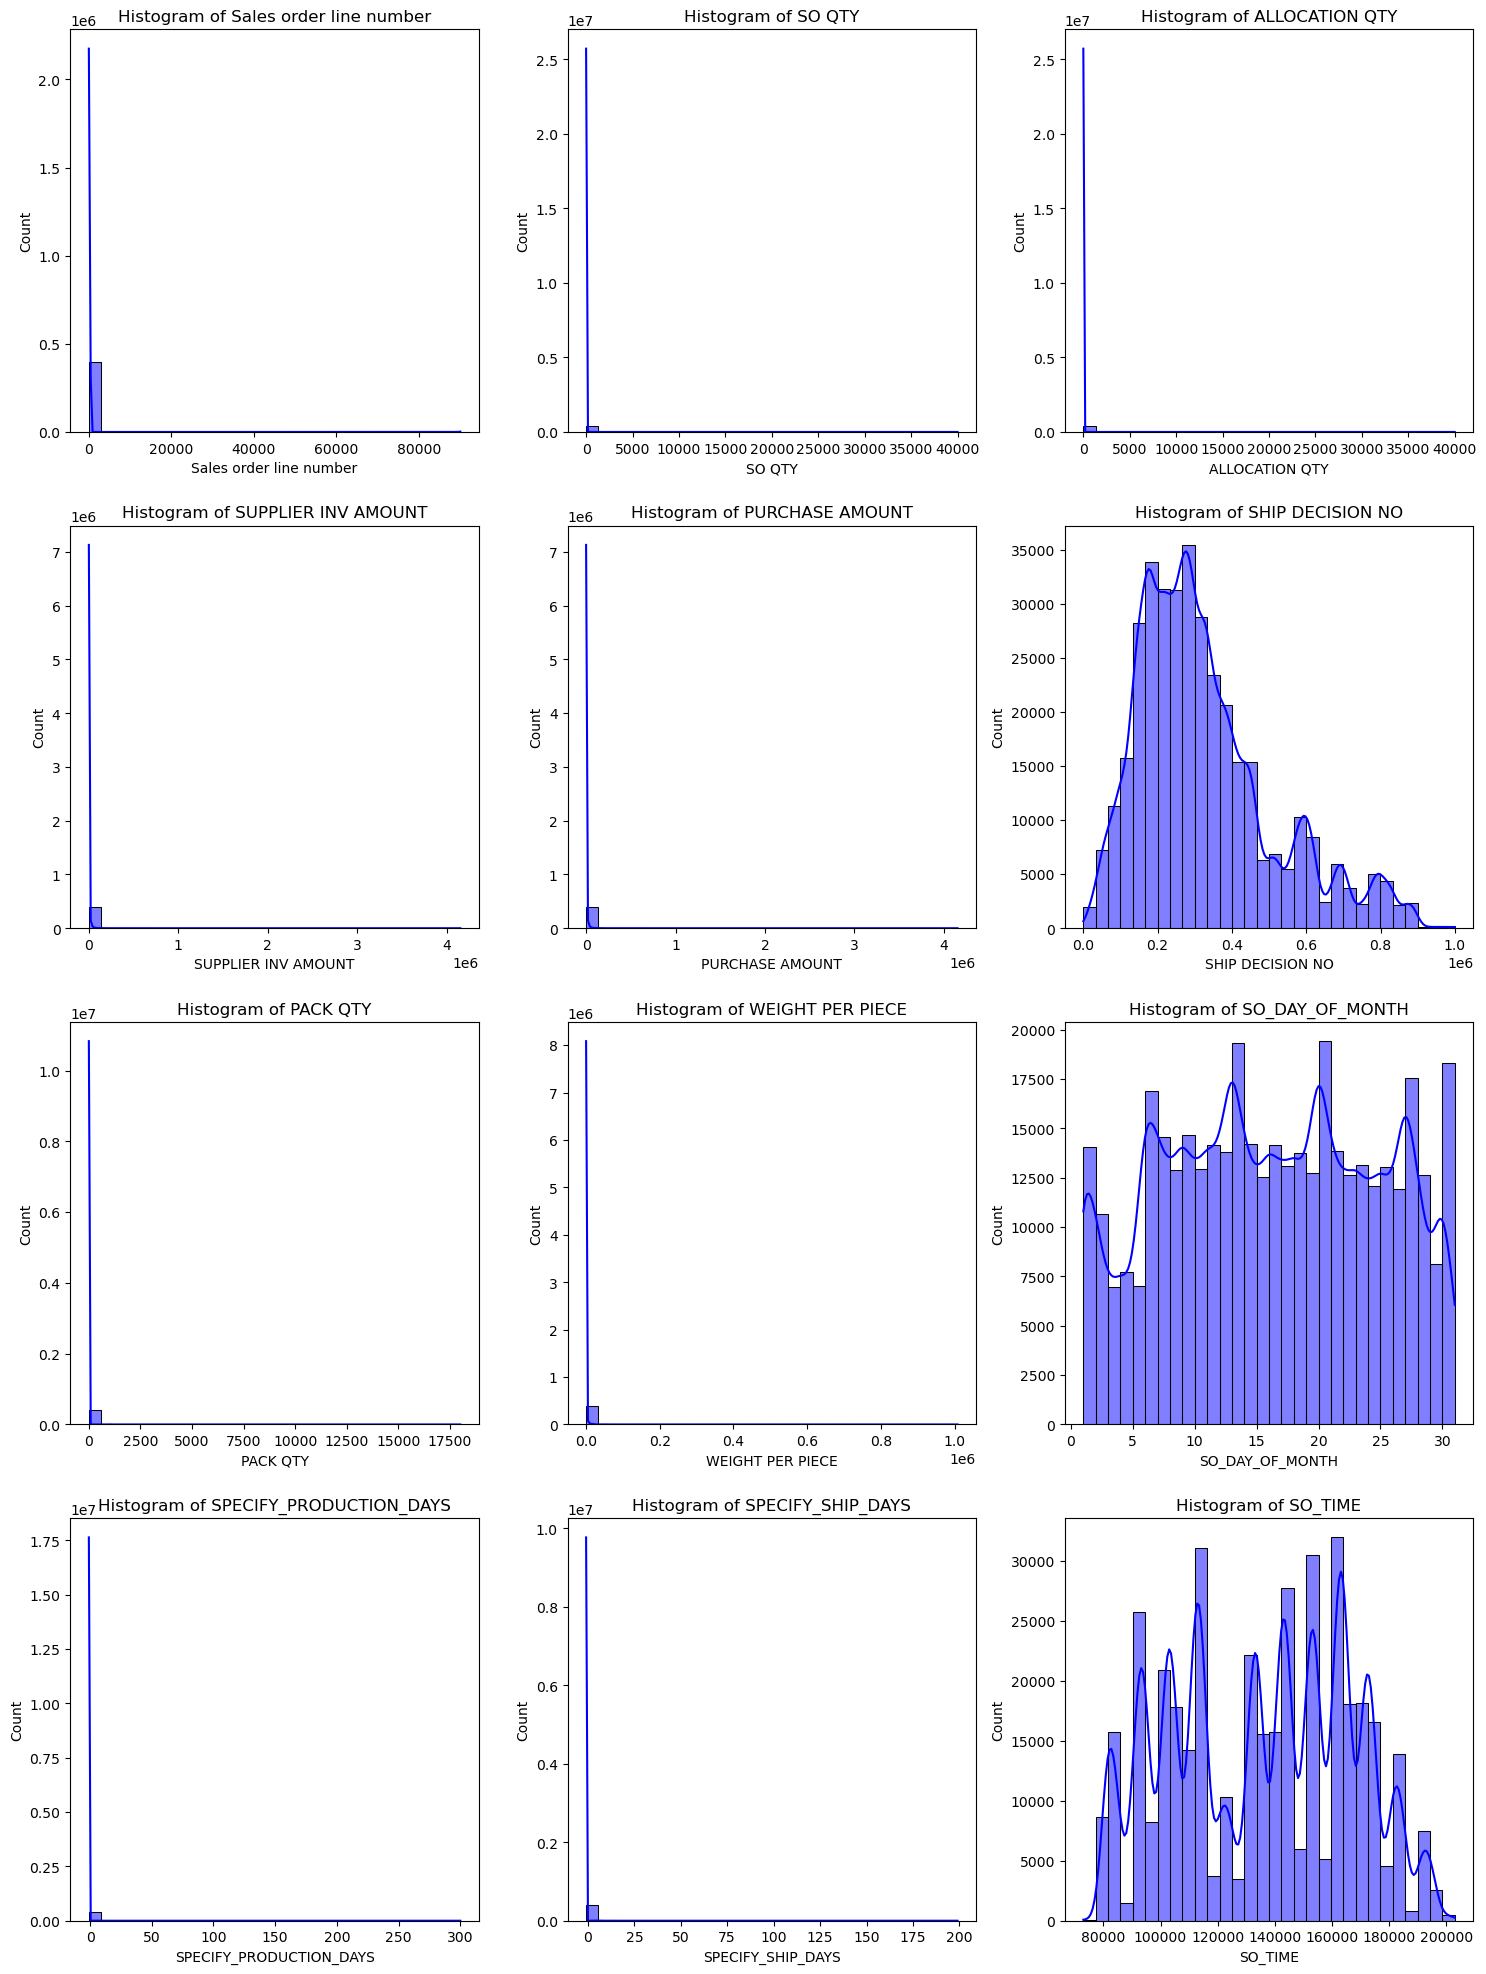

In [15]:
plot_histogram(df_4_6, num_cols_4_6)

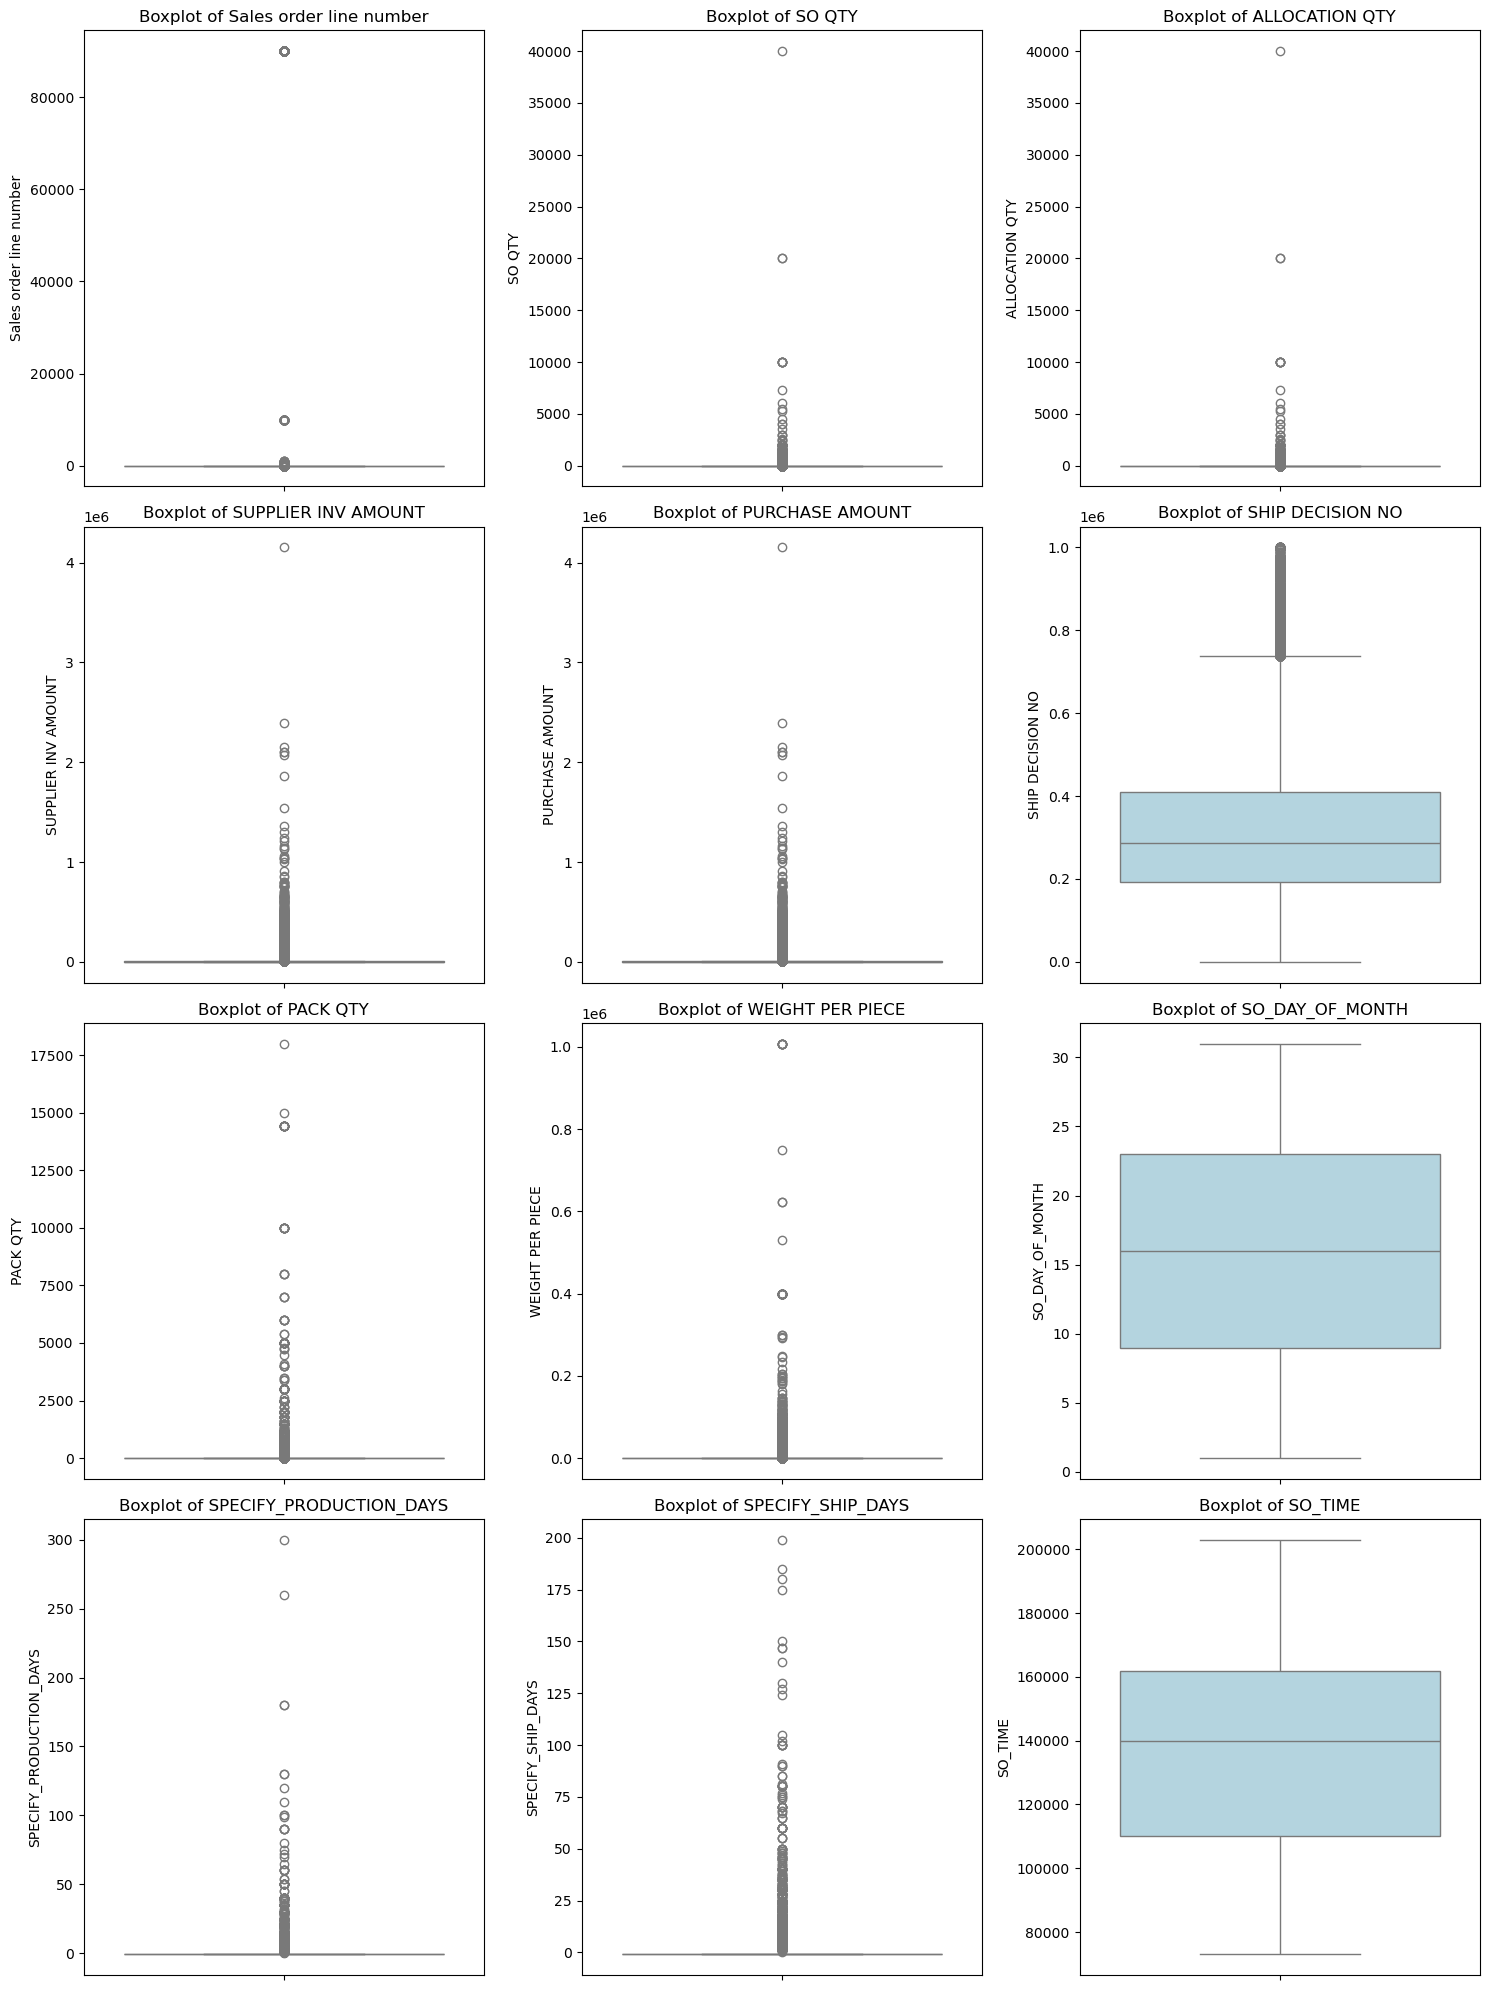

In [16]:
plot_boxplot(df_4_6, num_cols_4_6)

**1. Extremely Right-Skewed**
* *Features:* **SO QTY**, **ALLOCATION QTY**, **SUPPLIER INV AMOUNT**, **PURCHASE AMOUNT**, **PACK QTY**, **WEIGHT PER PIECE**, **SPECIFY_PRODUCTION_DAYS**, **SPECIFY_SHIP_DAYS**.
* *Insight:* 99% of values hover near zero, with a long tail of massive outliers representing rare, huge orders. The IQR is practically zero.

**2. Time-Based Features**
* *Features:* **SO_DAY_OF_MONTH**, **SO_TIME**.
* *Insight:* Pristine distributions with zero outliers. **SO_DAY_OF_MONTH** shows cyclical patterns. **SO_TIME** reveals peak ordering hours but is currently formatted as raw integers (HHMMSS).

**3. Pseudo-Continuous IDs**
* *Features:* **SHIP DECISION NO**.
* *Insight:* This is a generated ID code, not a real measurement. Its large values and structural outliers will introduce noise.

In [17]:
for col in cat_cols_4_6:
    print(f"--- Tần suất của cột: {col} ---")
    print(df_4_6[col].value_counts(dropna=False)) 
    print("-" * 40 + "\n")

--- Tần suất của cột: BRAND_CD ---
BRAND_CD
MSM1    348902
TRC1      3278
SA11      3045
SUS1      2148
ESC1      1889
         ...  
NKC1         1
FKO1         1
TJN1         1
DIL1         1
SRF1         1
Name: count, Length: 1755, dtype: int64
----------------------------------------

--- Tần suất của cột: CLASSIFY_CD ---
CLASSIFY_CD
3954109     37380
3954111     20454
3721101     16014
3643111     14020
3632307     13389
            ...  
21057712        1
21033803        1
6010173         1
3950098         1
21033603        1
Name: count, Length: 4106, dtype: int64
----------------------------------------

--- Tần suất của cột: CUST_CD ---
CUST_CD
769562    2899
743208    2273
511957    1526
292       1440
119889    1322
          ... 
337126       1
262868       1
580726       1
262735       1
150742       1
Name: count, Length: 39071, dtype: int64
----------------------------------------

--- Tần suất của cột: Consider count hodiday Saturday ---
Consider count hodiday Saturday

**1. Perfect Duplicates**
* *Features:* **PRODUCT ATTRIBUTION** & **Stock class**, **SPECIAL DIV** & **SPECIAL_DIV**.
* *Insight:* These pairs have perfectly identical data distributions, causing absolute data redundancy. And I need drop one columns is SPECIAL DIV or SPECIAL_DIV because they are duplicate.

**2. High-Cardinality Identifiers**
* *Features:* **PRODUCT_CD**, **INNER_CD**, **CUST_CD**, **CLASSIFY_CD**, **BRAND_CD**, **SUPPLIER_CD**.
* *Insight:* Contain an extreme number of unique categories. Traditional One-Hot Encoding here will cause RAM Out-of-Memory crashes.

**3. Ultra-Imbalanced Flags**
* *Features:* **IO_UNFIT_FLG**, **HEAVY_FLG**, **EXPENSIVE_FLG**.
* *Insight:* Severe zero-variance risk (almost 100% are "0"). Machine learning models will likely ignore these features.

**4. Missing Values & Dirty Data**
* *Features:* **Ship Mode**, **SUPPLIER_DIV**.
* *Insight:* Contain missing values (NaNs). **Ship Mode** also includes very rare, suspicious noisy categories.

**5. High-Potential Features**
* *Features:* **LOGICAL PLANT**, **SO_DAY_OF_WEEK**, **PACKING RANK**, **DIRECT SHIP FLG**.
* *Insight:* Well-distributed data that strongly reflects business patterns (e.g., clear volume drops on weekends in **SO_DAY_OF_WEEK**).

### ANALYZE BIVARIATE FOR DATASET APRIL TO JUNE

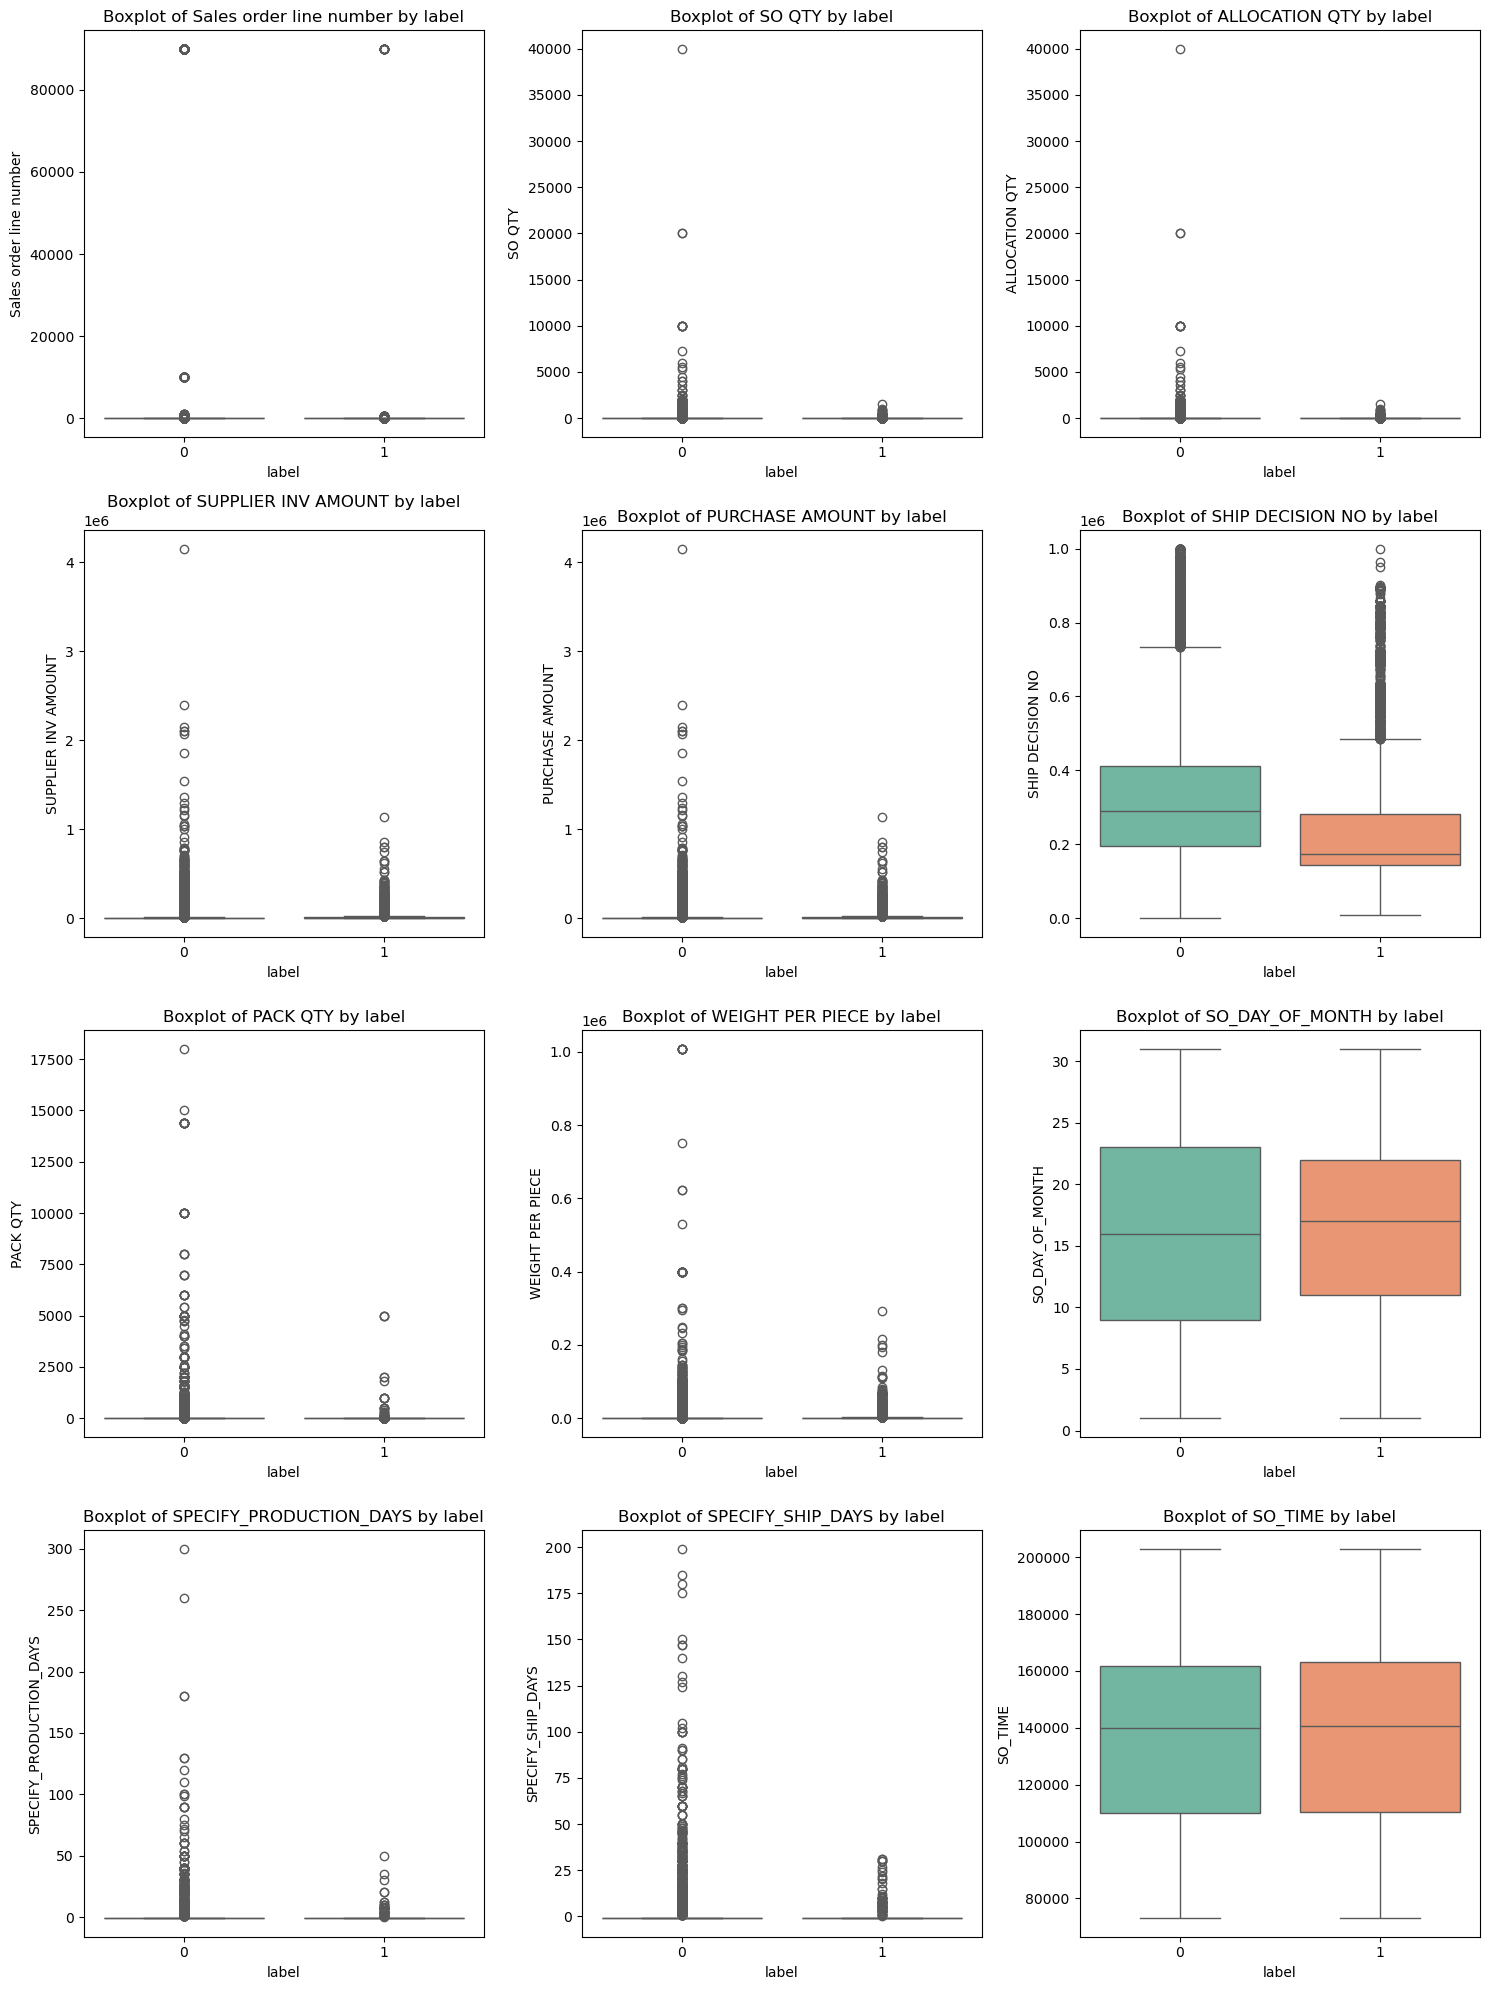

In [18]:
plot_bivariate_num_target(df_4_6, num_cols_4_6, target_col[0])

### Bivariate Analysis: Numerical Features vs. Target (Label)

**1. The "Whale" Phenomenon**
* *Features:* **SO QTY**, **ALLOCATION QTY**, **SUPPLIER INV AMOUNT**, **PURCHASE AMOUNT**, **PACK QTY**, **WEIGHT PER PIECE**, **SPECIFY_PRODUCTION_DAYS**, **SPECIFY_SHIP_DAYS**.
* *Observations:* Because of the extreme right-skewness, the interquartile ranges (boxes) for both Class 0 and Class 1 are entirely squashed near zero. However, a critical pattern emerges in the outliers: **The most extreme outliers (the absolute highest values) almost exclusively belong to Class 0 (Not Delayed).** The maximum values for Class 1 are significantly lower across all these metrics.
* *Business Insight:* Massive orders are highly valuable shipments rarely experience delays. This could indicate that the business prioritizes large/expensive orders, ensuring they are fulfilled on time, while smaller or standard orders are more prone to logistical slipping.

**2. Time-Based Patterns**
* *Feature:* **SO_DAY_OF_MONTH**
  * *Observations:* The median and the overall box for Class 1 (orange) are positioned slightly higher than Class 0 (green). 
  * *Insight:* Orders placed later in the month have a slightly higher tendency to be delayed, possibly due to end-of-month volume bottlenecks.
* *Feature:* **SO_TIME**
  * *Observations:* The distributions for Class 0 and Class 1 are almost perfectly identical. 
  * *Insight:* In its raw integer format, **SO_TIME** lacks discriminative power.

**3. Continuous ID**
* *Feature:* **SHIP DECISION NO**
* *Observations:* There is a distinct shift. Class 1 has a noticeably lower median than Class 0, and its outliers are heavily clustered at the upper boundary.
* *Insight:* Since this is likely an incremental ID, lower numbers represent older orders. This indicates that delays are chronologically biased (e.g., a specific past period had more delays). Using this raw ID in a predictive model could lead to severe overfitting on historical timelines rather than learning actual shipping logic.

=>> I will drop the SHIP DECISION NO because it have high uniqueness.

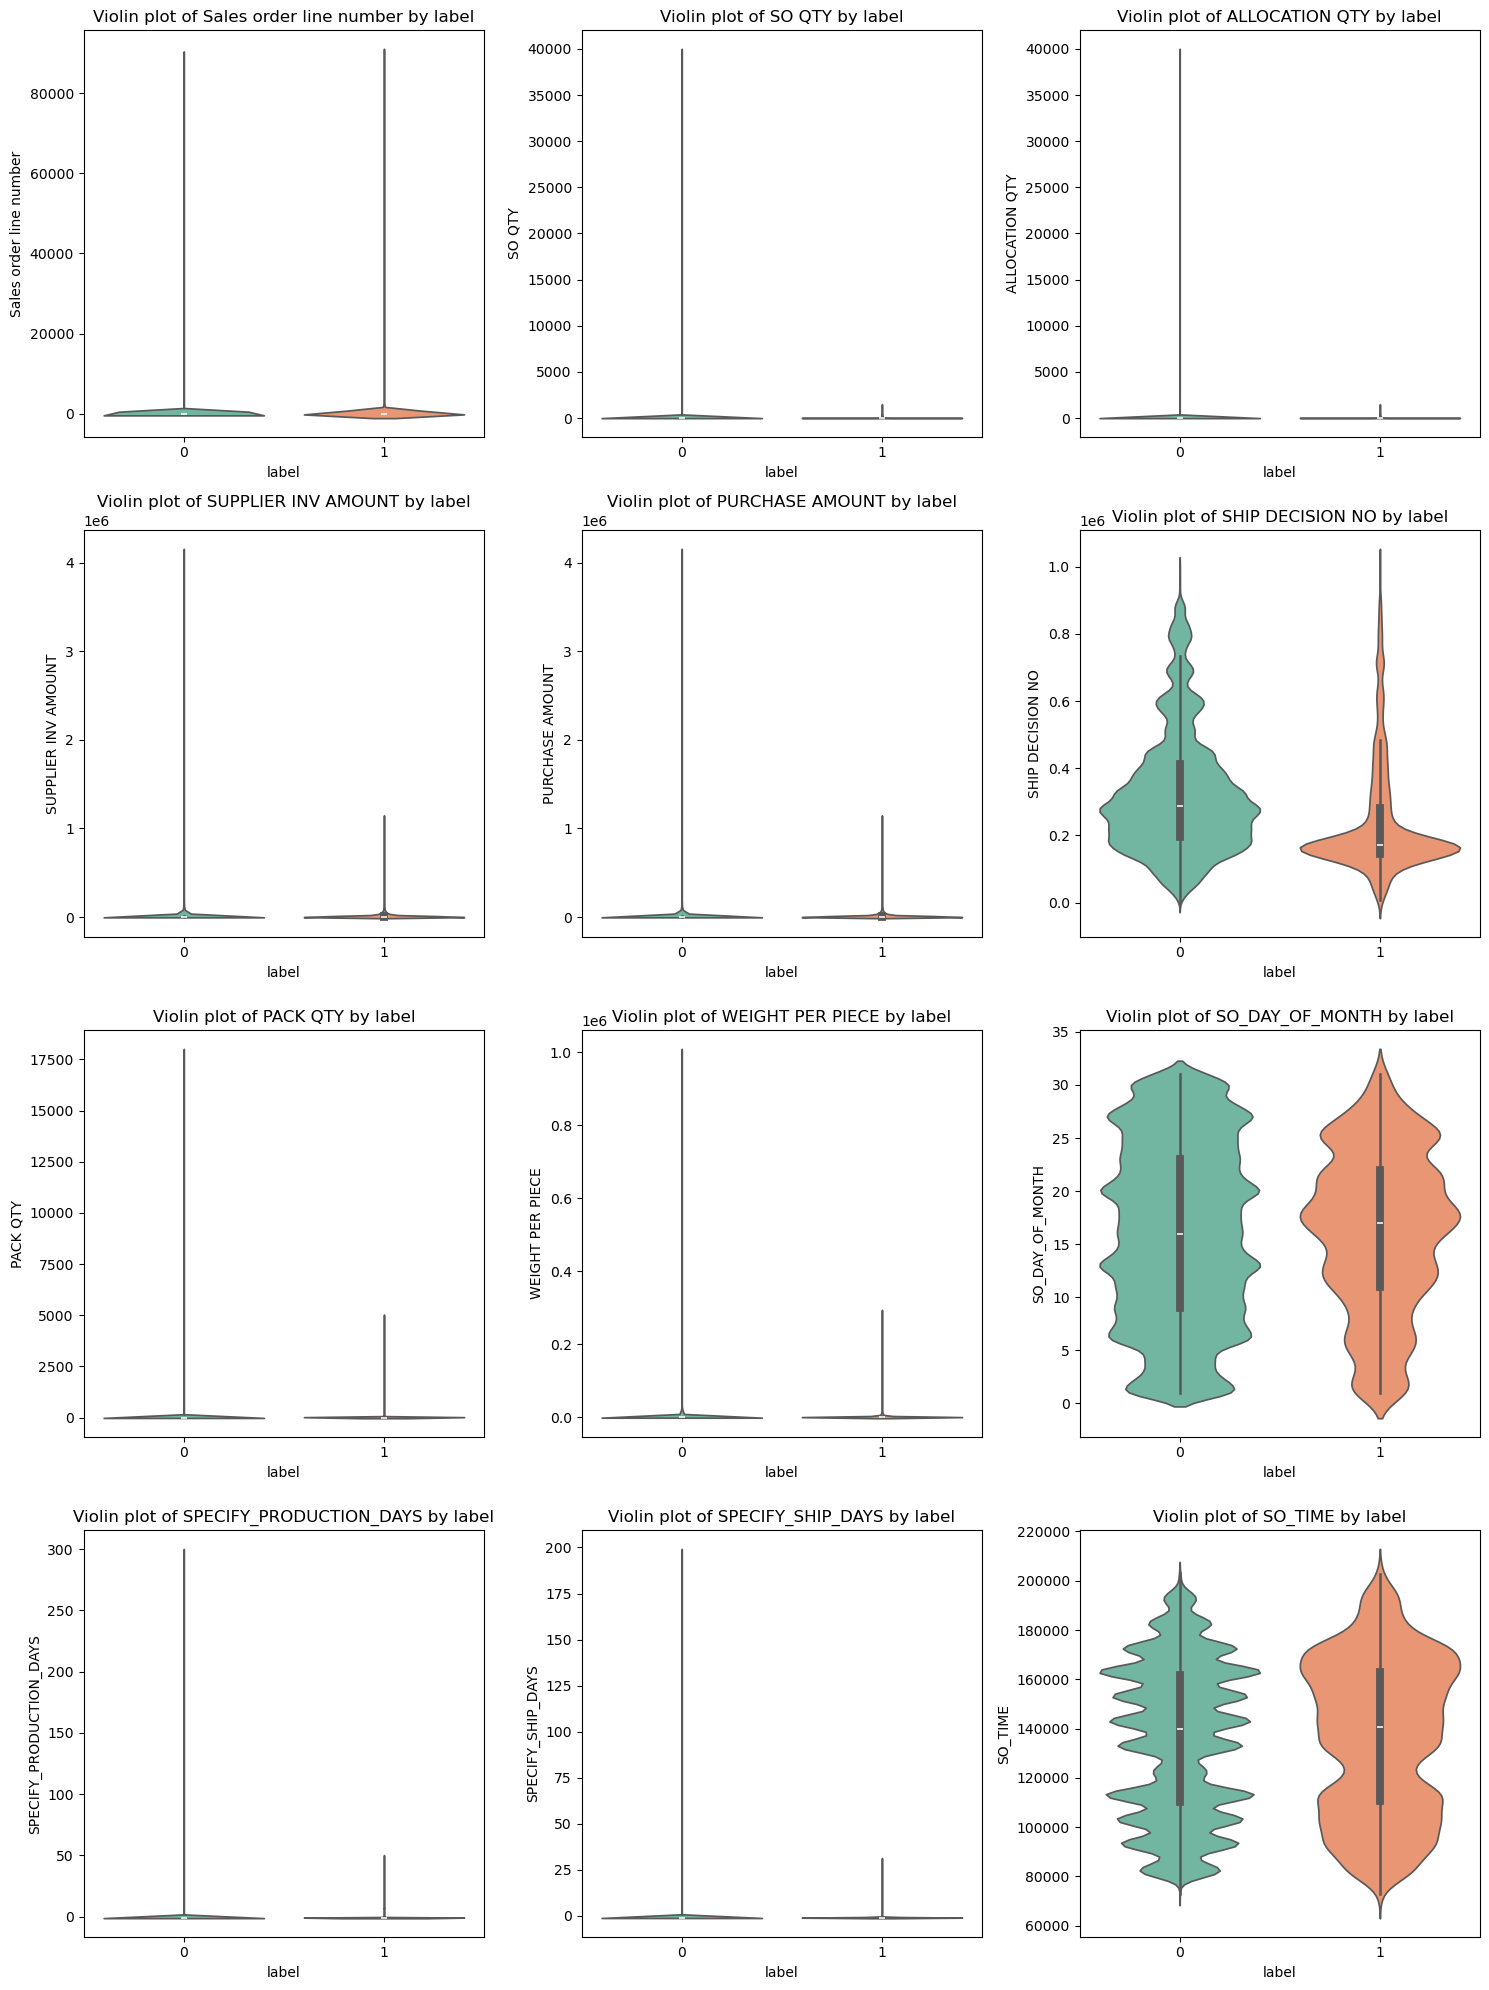

In [19]:
plot_bivariate_num_target(df_4_6, num_cols_4_6, target_col[0], plot_type='violin_plot')

The list of columns for Countplot: ['Consider count hodiday Saturday', 'DELI_DIV', 'DIRECT SHIP FLG', 'EXPENSIVE_FLG', 'HEAVY_FLG', 'IO_UNFIT_FLG', 'LOGICAL PLANT', 'PACKING RANK', 'PRODUCT ATTRIBUTION', 'SO_DAY_OF_WEEK', 'SPECIAL DIV', 'SPECIAL_DIV', 'SUPPLIER_CATEGORY_CD', 'SUPPLIER_DIV', 'Ship Mode', 'Stock class']


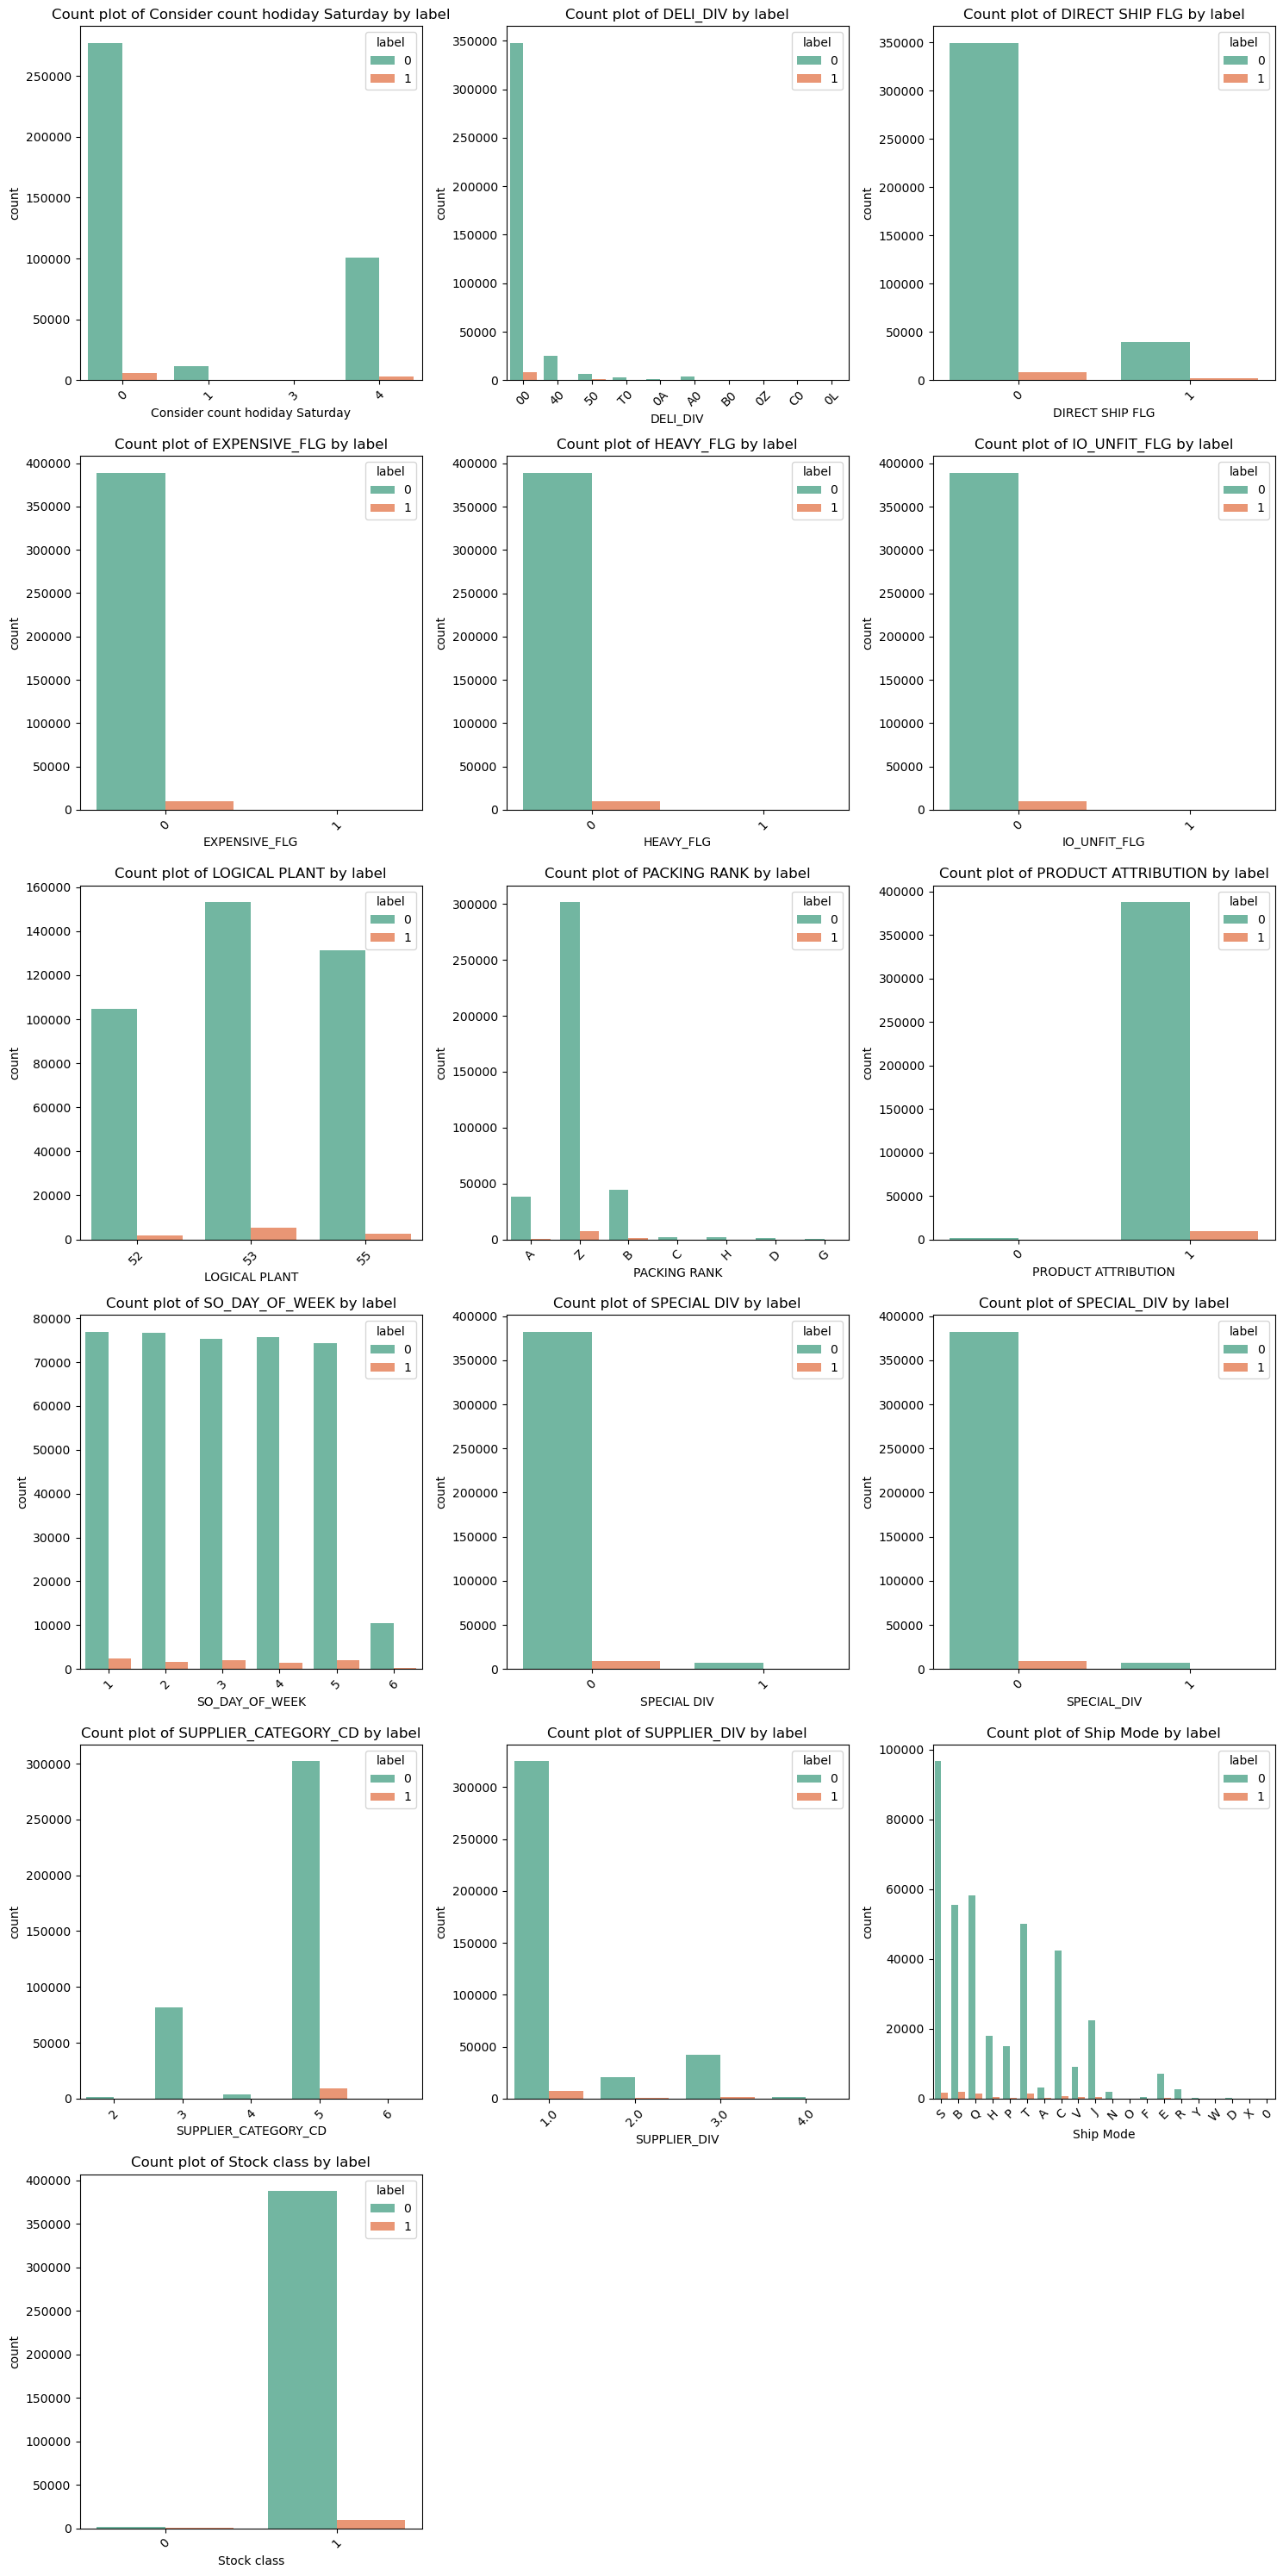

In [20]:
cat_cols_to_plot = [col for col in cat_cols_4_6 if df_4_6[col].nunique() <= 20]
print(f"The list of columns for Countplot: {cat_cols_to_plot}")

plot_bivariate_cat_target(df_4_6, cat_cols_to_plot, target_col='label')

### Bivariate Analysis: Categorical Features vs Target

**1. Serve Class Imbalance**
- All the chart show that label 0 overwhelmingly dominate label 1. So the dataset is highly imbalanced. I will use some methods such as: SMOTE, UNDERSAMPLING, CLASS WEIGHT,...

**2. Redundant Features**
- Features like **EXPENSIVE_FLG**, **HEAVY_FLG**, **IO_UNFIT_FLG**, **SPECIAL DIV** only show immense green pillar in class 0, they do not show anythings in class 1.
- Features like **PRODUCT ATTRIBUTION**, **Stock class** are the same because they are about the order whether in stock or not. I will drop one of the two features. 

In [21]:
chi_square_results = perform_chi_square_test(df_4_6, cat_cols_4_6, target_col='label')

--- TABLE OF CHI-SQUARE TESTING (Target: label) ---

Feature                   | p-value              | Conclusion
---------------------------------------------------------------------------
BRAND_CD                  | 0.00000e+00          | Has an effect
CLASSIFY_CD               | 0.00000e+00          | Has an effect
CUST_CD                   | 0.00000e+00          | Has an effect
DELI_DIV                  | 0.00000e+00          | Has an effect
INNER_CD                  | 0.00000e+00          | Has an effect
SUPPLIER_CATEGORY_CD      | 0.00000e+00          | Has an effect
SUPPLIER_CD               | 0.00000e+00          | Has an effect
LOGICAL PLANT             | 3.61360e-229         | Has an effect
Ship Mode                 | 9.41750e-225         | Has an effect
SUPPLIER_DIV              | 9.69861e-200         | Has an effect
DIRECT SHIP FLG           | 3.09721e-116         | Has an effect
Consider count hodiday Saturday | 1.49237e-69          | Has an effect
SPECIAL DIV            

### CHI-SQUARE TESTING
- I will drop **IO_UNFIT_FLG**, **HEAVY_FLG**, **EXPENSIVE_FLG**, **Stock class**, **SPECIAL DIV**. Because Stock class and SPECIAL DIV are duplicate AND IO_UNFIT_FLG, HEAVY_FLG, EXPENSIVE_FLG have no effect. EXPENSIVE_FLG show that it have effect because the sample size is large and they saw in previouse countplot, it is not meaningful for dataset.

In [22]:
df_4_6[cat_cols_4_6].nunique()

BRAND_CD                             1755
CLASSIFY_CD                          4106
CUST_CD                             39071
Consider count hodiday Saturday         4
DELI_DIV                               10
DIRECT SHIP FLG                         2
EXPENSIVE_FLG                           2
HEAVY_FLG                               2
INNER_CD                           110113
IO_UNFIT_FLG                            2
LOGICAL PLANT                           3
PACKING RANK                            7
PRODUCT ATTRIBUTION                     2
PRODUCT_CD                         302479
SO_DAY_OF_WEEK                          6
SPECIAL DIV                             2
SPECIAL_DIV                             2
SUPPLIER_CATEGORY_CD                    5
SUPPLIER_CD                           877
SUPPLIER_DIV                            4
Ship Mode                              20
Stock class                             2
dtype: int64

In [23]:
cols_to_drop = [
    'SPECIAL_DIV',       
    'Stock class',        
    'IO_UNFIT_FLG',      
    'HEAVY_FLG',          
    'EXPENSIVE_FLG',     
    'SHIP DECISION NO',
    'PRODUCT_CD',
    'INNER_CD'
]

df_4_6 = df_4_6.drop(columns=cols_to_drop, errors='ignore')

cat_cols_4_6 = [col for col in cat_cols_4_6 if col not in cols_to_drop]
num_cols_4_6 = [col for col in num_cols_4_6 if col not in cols_to_drop]

print("Completly drop columns: ", cols_to_drop)
print(f"The size of the dataset is: {df_4_6.shape}")

Completly drop columns:  ['SPECIAL_DIV', 'Stock class', 'IO_UNFIT_FLG', 'HEAVY_FLG', 'EXPENSIVE_FLG', 'SHIP DECISION NO', 'PRODUCT_CD', 'INNER_CD']
The size of the dataset is: (399053, 29)


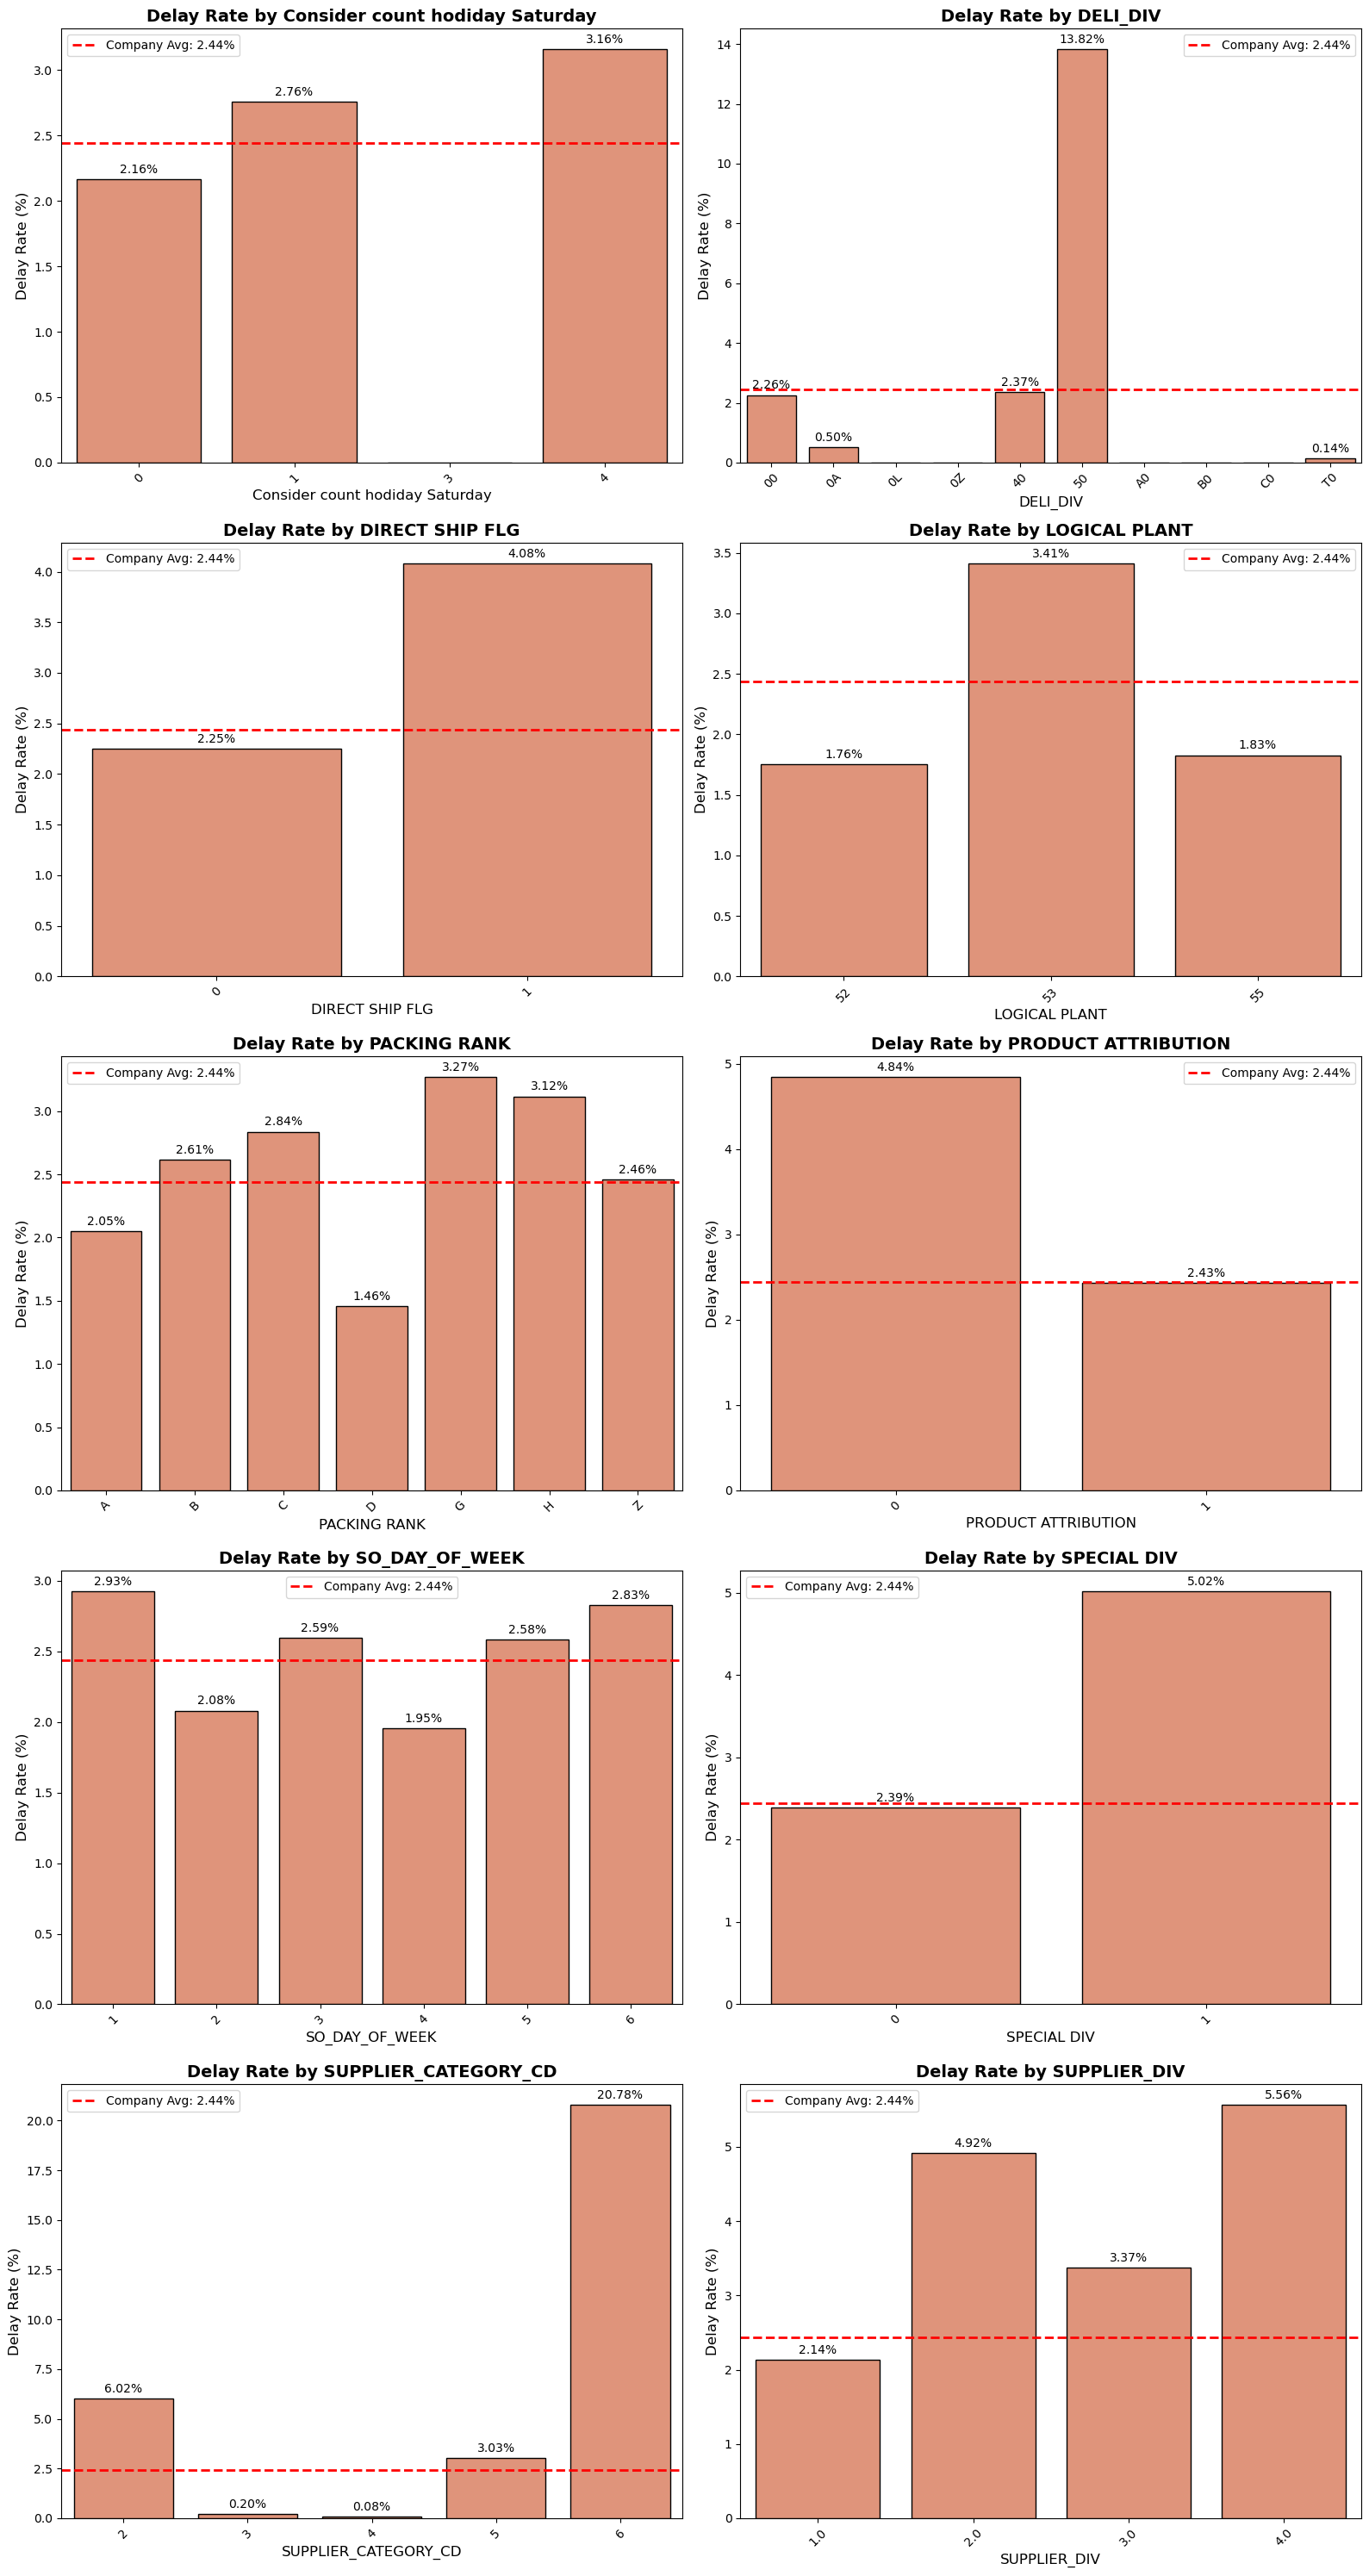

In [24]:
plot_delay_rate(df_4_6, cat_cols_4_6, target_col='label')

Ship Mode
S          98354
Q          59735
B          57313
T          51514
C          43248
J          22841
H          18401
P          15175
V           9484
E           7398
Unknown     6588
A           3342
R           2688
N           1958
F            608
Y            234
D            117
Other         55
Name: count, dtype: int64


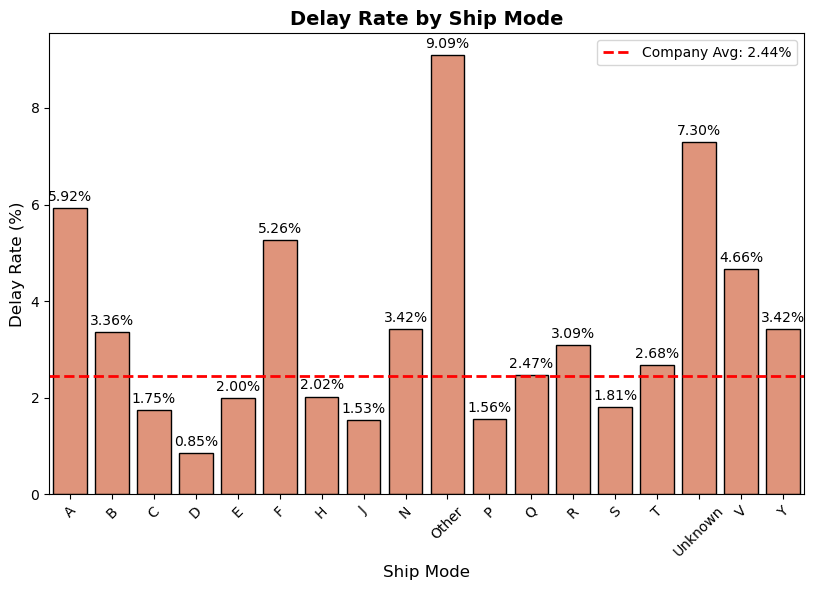

In [25]:
df_4_6['Ship Mode'] = df_4_6['Ship Mode'].fillna('Unknown')


ship_mode_counts = df_4_6['Ship Mode'].value_counts()
rare_modes = ship_mode_counts[ship_mode_counts < 100].index


df_4_6['Ship Mode'] = df_4_6['Ship Mode'].replace(rare_modes, 'Other')

print(df_4_6['Ship Mode'].value_counts())

plot_delay_rate(df_4_6, ['Ship Mode'], target_col='label')

### ANALYZE MULTI-VARIATE FOR DATASET APRIL TO JUNE

Calculating correlation matrix using 'SPEARMAN' method


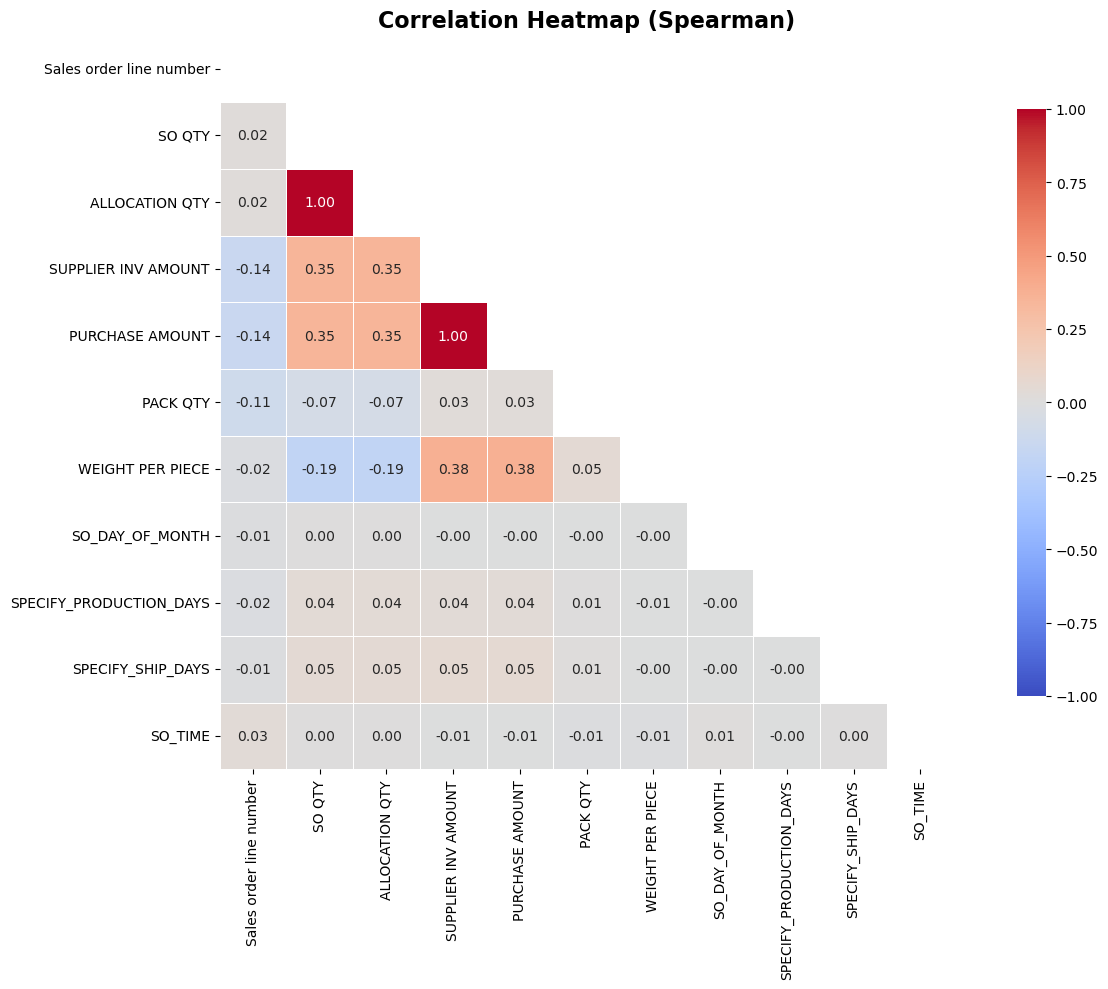

MULTICOLLINEARITY WARNING SYSTEM (Threshold 0.8) 
Feature Pair: [ALLOCATION QTY] and [SO QTY]
Correlation level: 1.00
Recommendation: Consider DROPPING one of these two features

Feature Pair: [PURCHASE AMOUNT] and [SUPPLIER INV AMOUNT]
Correlation level: 1.00
Recommendation: Consider DROPPING one of these two features



In [26]:
plot_correlation_heatmap(df_4_6, num_cols_4_6)

### ANALYZE MULTI-VARIATE 
- Because the (ALLOCATION QTY AND SO QTY) and (PURCHASE AMOUNT AND SUPPLIER INV AMOUNT) are the multicllinearity, I will drop SUPPLIER INV AMOUNT and ALLOCATION QTY.

In [27]:
df_4_6.drop(columns=['ALLOCATION QTY', 'SUPPLIER INV AMOUNT'], inplace=True, errors='ignore')
num_cols_4_6 = [col for col in num_cols_4_6 if col not in ['ALLOCATION QTY', 'SUPPLIER INV AMOUNT']]

In [28]:
df_4_6.shape

(399053, 27)

### ANALYZE UNIVARIATE FOR DATASET JULT TO SEPTEMBER

In [29]:
df_7_9.shape

(1074897, 31)

In [30]:
df_7_9.dtypes

Order date                         datetime64[ns]
CLASSIFY_CD                                 int64
CUST_CD                                     int64
BRAND_CD                                   object
INNER_CD                                   object
SUPPLIER_CD                                object
Sales order line number                     int64
Stock class                                 int64
Consider count hodiday Saturday             int64
SO QTY                                      int64
ALLOCATION QTY                              int64
SUPPLIER INV AMOUNT                       float64
PACKING RANK                               object
PRODUCT_CD                                 object
PRODUCT ATTRIBUTION                         int64
SPECIAL DIV                                 int64
LOGICAL PLANT                               int64
PURCHASE AMOUNT                           float64
VSD                                datetime64[ns]
DIRECT SHIP FLG                             int64


In [31]:
target_col = ['label']
date_cols = ['Order date', 'VSD']

In [32]:
num_cols_7_9 = ['Sales order line number',
                'SO QTY',
                'ALLOCATION QTY',
                'SUPPLIER INV AMOUNT',
                'PURCHASE AMOUNT',
                'SHIP DECISION NO',
                'PACK QTY',
                'WEIGHT PER PIECE',
                'SO_DAY_OF_MONTH',
                'SO_TIME'
]
cat_cols_7_9 = df_7_9.columns.difference(num_cols_7_9).difference(target_col).difference(date_cols).tolist()

In [33]:
# Display summary statistics for numerical columns
display_summary_statistics(df_7_9, num_cols_7_9)

,Sales order line number,SO QTY,ALLOCATION QTY,SUPPLIER INV AMOUNT,PURCHASE AMOUNT,SHIP DECISION NO,PACK QTY,WEIGHT PER PIECE,SO_DAY_OF_MONTH,SO_TIME
count,1.074897e+06,1.074897e+06,1.074897e+06,1.074897e+06,1.074897e+06,1.003483e+06,1.074897e+06,1.074897e+06,1.074897e+06,1.074897e+06
mean,1.546860e+02,7.733413e+00,7.733413e+00,5.839892e+03,5.841247e+03,3.544376e+05,3.487939e+00,8.272667e+02,1.534687e+01,1.345315e+05
std,3.356841e+03,1.309622e+02,1.309622e+02,2.962142e+04,2.962182e+04,1.860070e+05,1.237256e+02,5.866777e+03,9.132382e+00,3.220171e+04
min,1.000000e+00,1.000000e+00,1.000000e+00,8.400000e-01,0.000000e+00,4.404000e+03,0.000000e+00,0.000000e+00,1.000000e+00,1.040700e+04
25%,1.000000e+00,1.000000e+00,1.000000e+00,7.120000e+02,7.120000e+02,2.169250e+05,0.000000e+00,1.600000e+01,7.000000e+00,1.053230e+05
50%,3.000000e+00,2.000000e+00,2.000000e+00,1.776000e+03,1.776000e+03,3.186130e+05,0.000000e+00,1.000000e+02,1.500000e+01,1.358350e+05
75%,1.200000e+01,4.000000e+00,4.000000e+00,4.600000e+03,4.600000e+03,4.605290e+05,0.000000e+00,4.500000e+02,2.300000e+01,1.621410e+05
max,9.005000e+04,9.000000e+04,9.000000e+04,1.214400e+07,1.214400e+07,9.666290e+05,2.500000e+04,1.300000e+06,3.100000e+01,2.030000e+05


In [34]:
# Calculate skewness for numerical columns
calculate_skewness(df_7_9, num_cols_7_9)

Sales order line number     26.588044
SO QTY                     386.532211
ALLOCATION QTY             386.532211
SUPPLIER INV AMOUNT        118.139163
PURCHASE AMOUNT            118.134331
SHIP DECISION NO             0.735552
PACK QTY                    87.043522
WEIGHT PER PIECE            58.724994
SO_DAY_OF_MONTH              0.051263
SO_TIME                     -0.085687
dtype: float64

In [35]:
# Calculate kurtosis for numerical columns
calculate_kurtosis(df_7_9, num_cols_7_9)

Sales order line number       708.448767
SO QTY                     228855.997612
ALLOCATION QTY             228855.997612
SUPPLIER INV AMOUNT         33140.256542
PURCHASE AMOUNT             33138.460352
SHIP DECISION NO                0.075018
PACK QTY                    10159.832945
WEIGHT PER PIECE             5812.648462
SO_DAY_OF_MONTH                -1.286605
SO_TIME                        -1.097381
dtype: float64

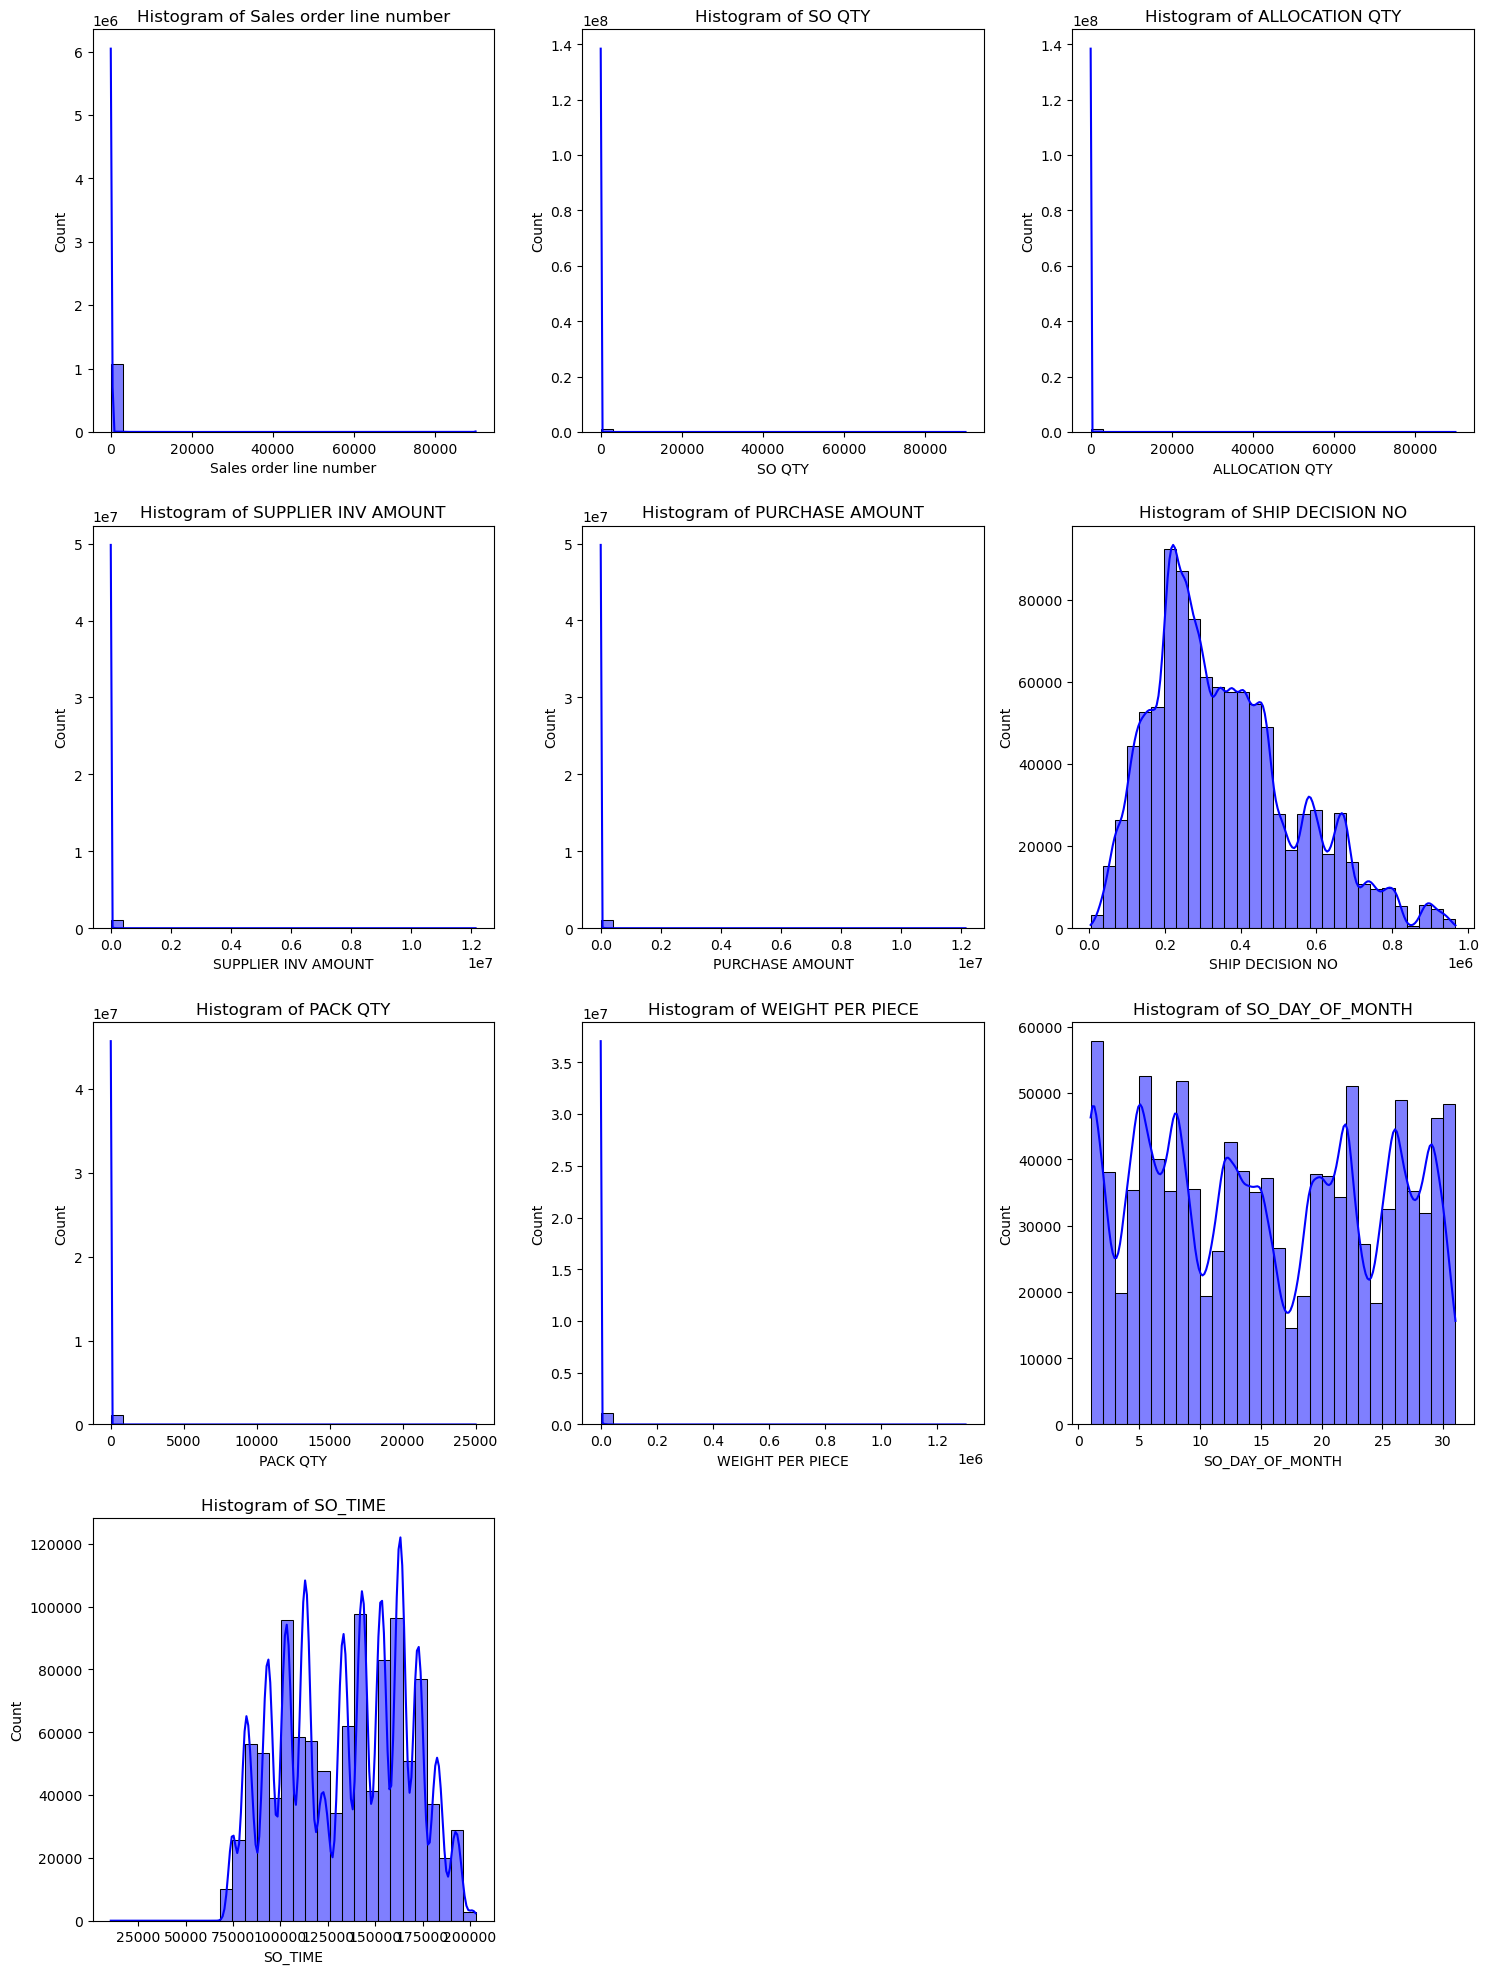

In [36]:
plot_histogram(df_7_9, num_cols_7_9)

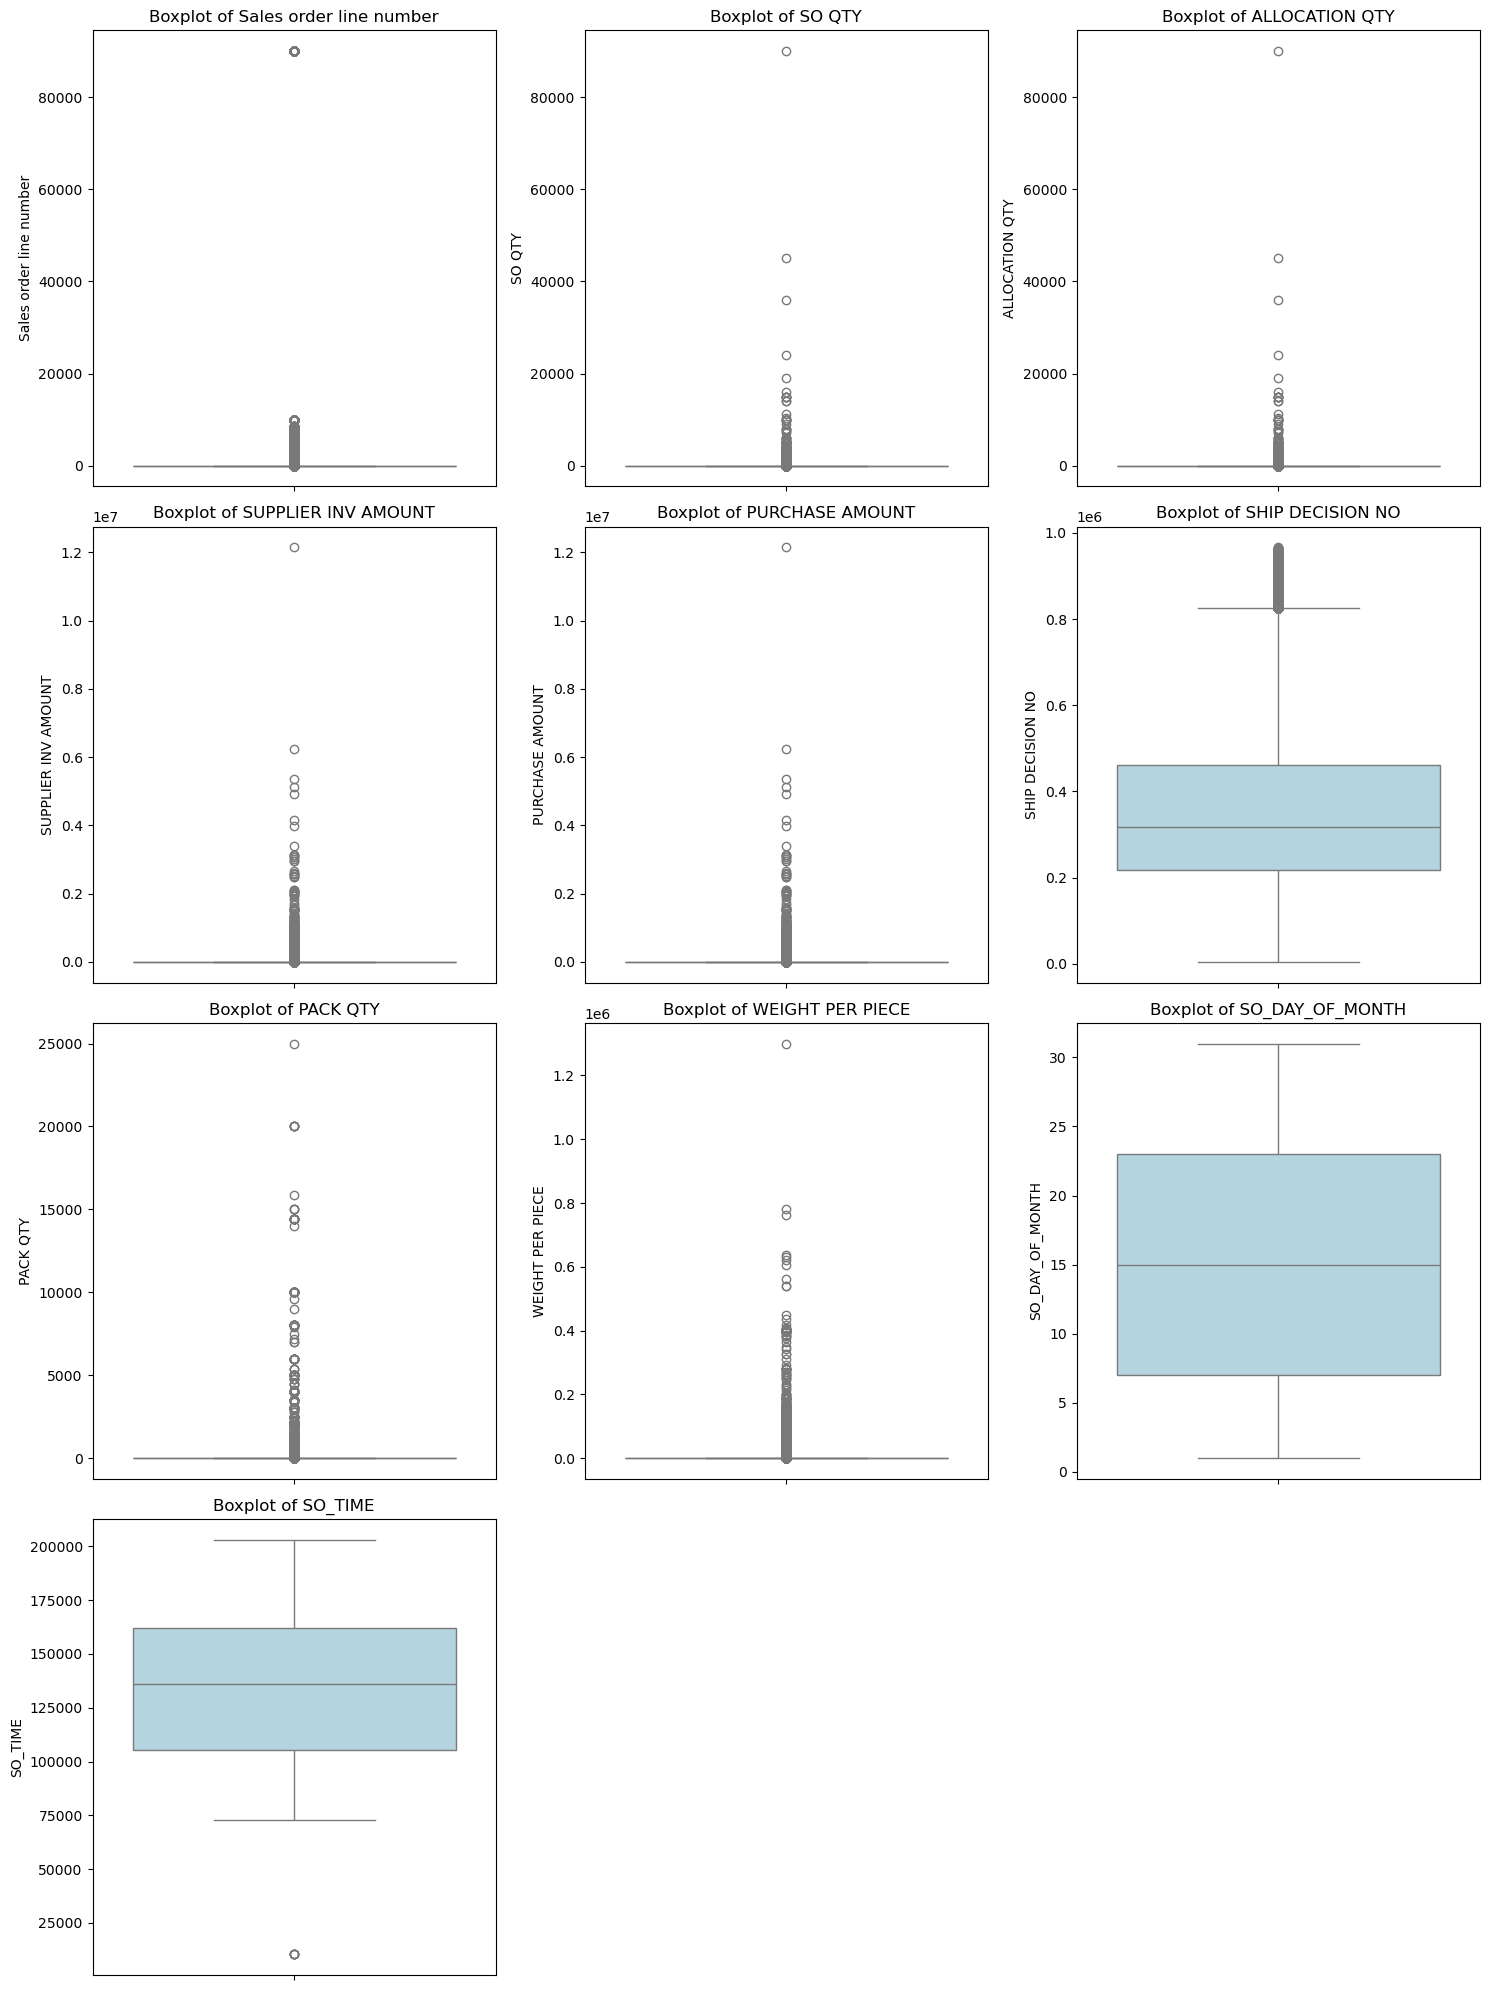

In [37]:
plot_boxplot(df_7_9, num_cols_7_9)

In [38]:
for col in cat_cols_7_9:
    print(f"--- Tần suất của cột: {col} ---")
    print(df_7_9[col].value_counts(dropna=False)) 
    print("-" * 40 + "\n")

--- Tần suất của cột: BRAND_CD ---
BRAND_CD
MSM1    937736
SA11      9609
TRC1      9080
SUS1      5075
ESC1      4978
         ...  
ATV1         1
CQ81         1
SWY1         1
B911         1
BFC1         1
Name: count, Length: 2014, dtype: int64
----------------------------------------

--- Tần suất của cột: CLASSIFY_CD ---
CLASSIFY_CD
3954109     94245
3954111     51057
3721101     41251
3643111     34118
3632307     31640
            ...  
21034815        1
23011992        1
21046799        1
23027930        1
5031314         1
Name: count, Length: 5035, dtype: int64
----------------------------------------

--- Tần suất của cột: CUST_CD ---
CUST_CD
254252    21376
62843     21201
251577    17222
147666    14645
142741    13864
          ...  
84575         1
292150        1
730652        1
752195        1
294170        1
Name: count, Length: 51456, dtype: int64
----------------------------------------

--- Tần suất của cột: Consider count hodiday Saturday ---
Consider count hodid

### ANALYZE BIVARIATE FOR DATASET JULY TO SEPTEMBER

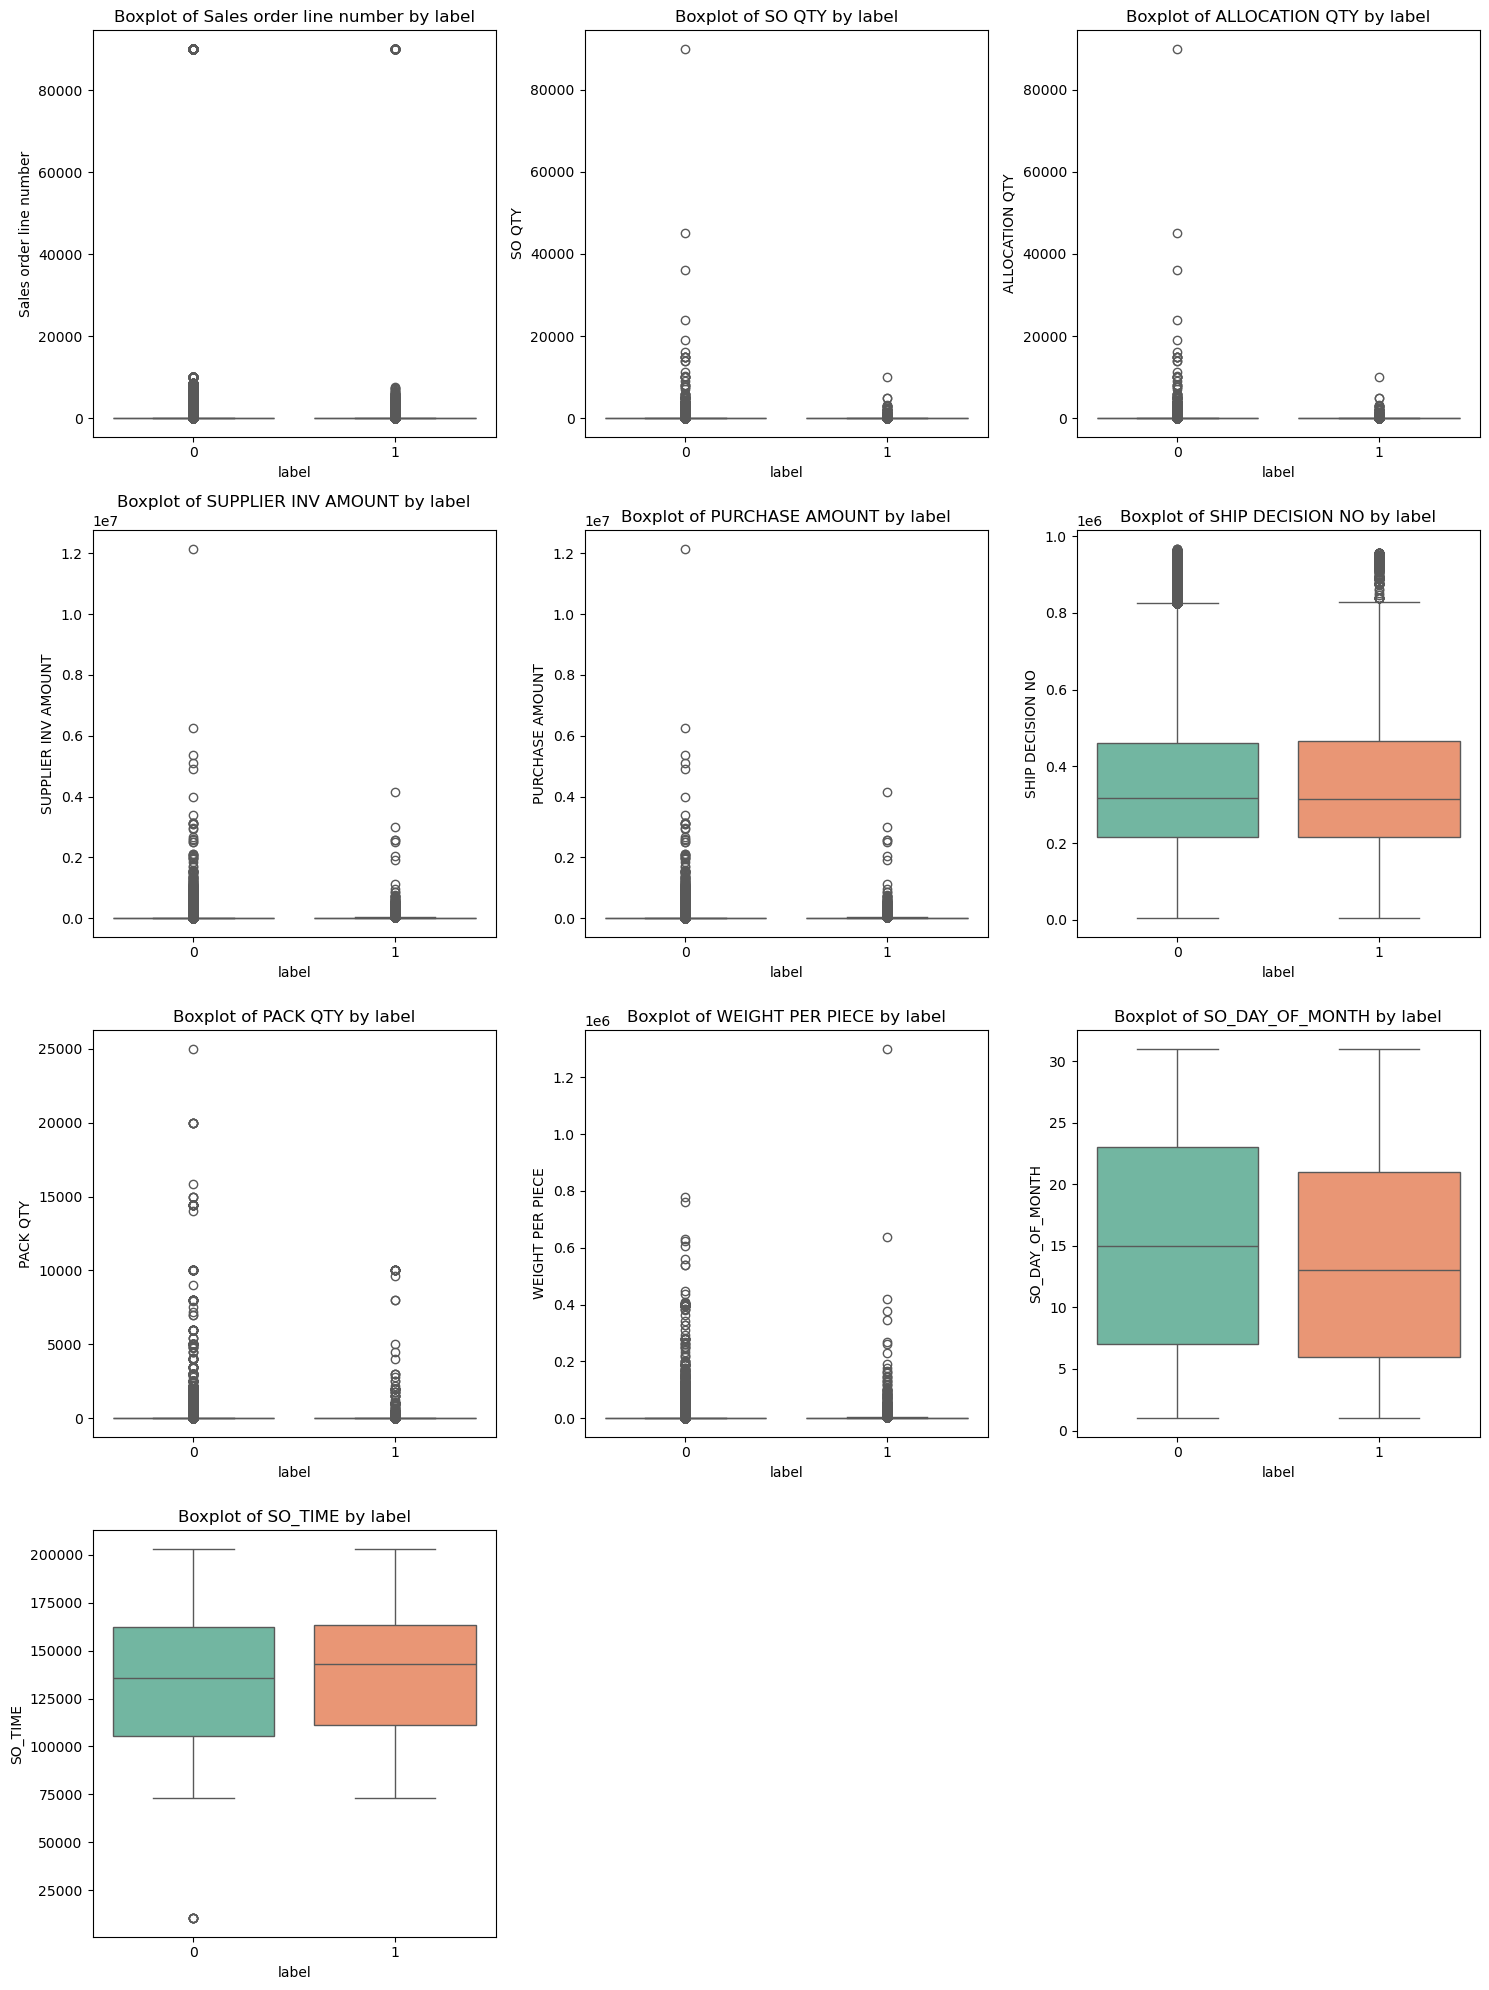

In [39]:
plot_bivariate_num_target(df_7_9, num_cols_7_9, target_col[0])

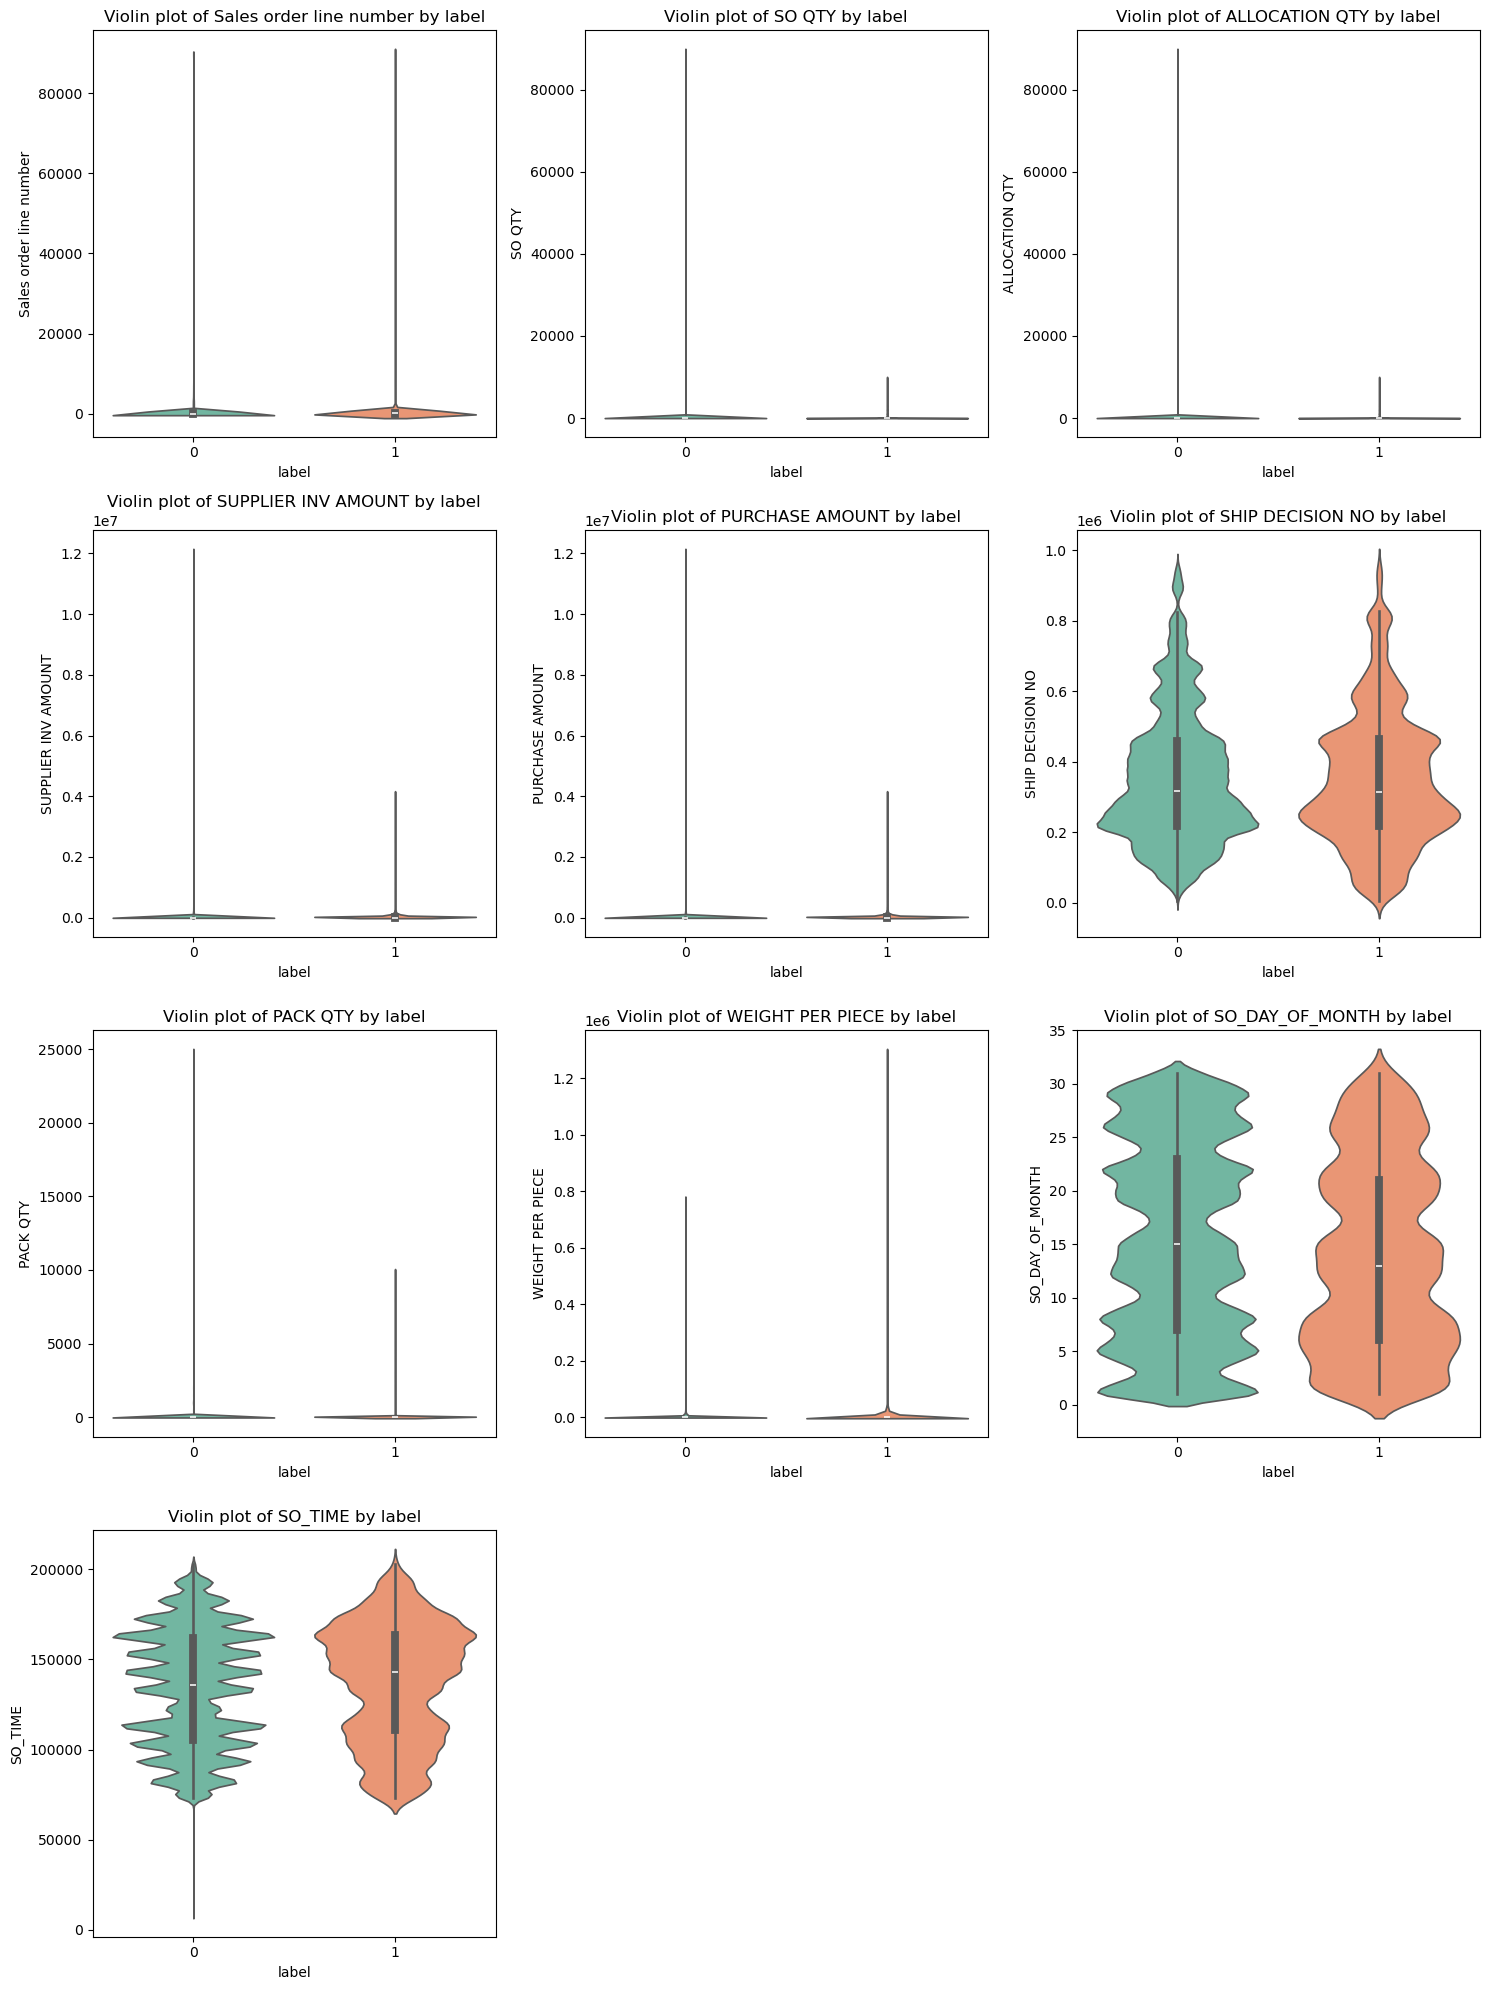

In [40]:
plot_bivariate_num_target(df_7_9, num_cols_7_9, target_col[0], plot_type='violin_plot')

The list of columns for Countplot: ['Consider count hodiday Saturday', 'DELI_DIV', 'DIRECT SHIP FLG', 'LOGICAL PLANT', 'PACKING RANK', 'PRODUCT ATTRIBUTION', 'SO_DAY_OF_WEEK', 'SPECIAL DIV', 'SPECIAL_DIV', 'SUPPLIER_DIV', 'Ship Mode', 'Stock class']


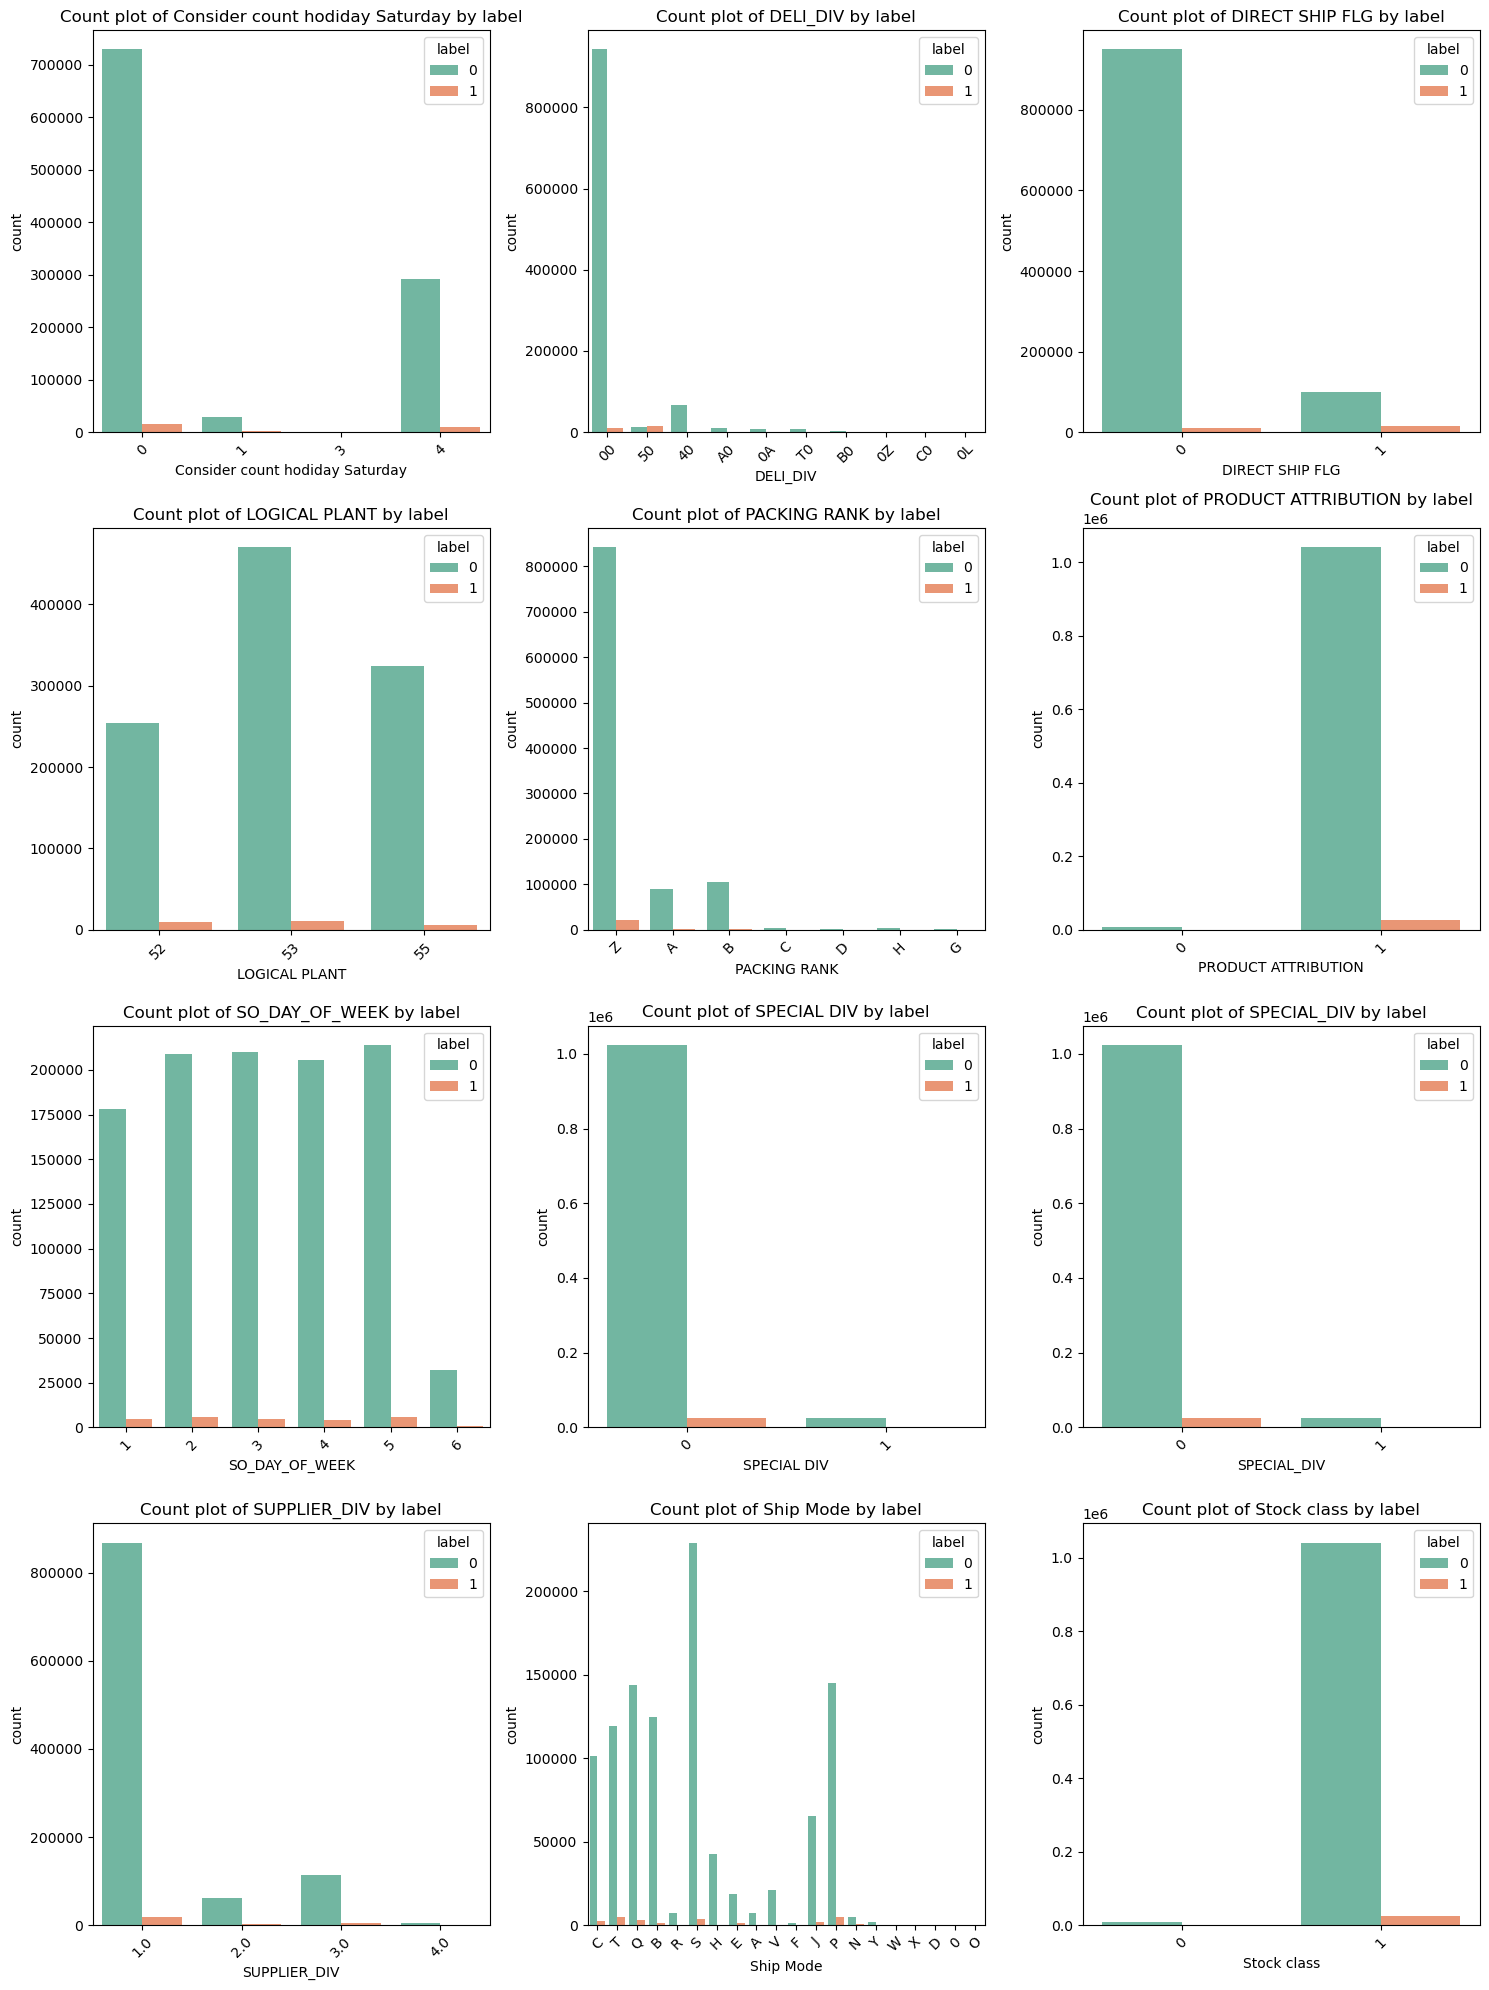

In [41]:
cat_cols_to_plot = [col for col in cat_cols_7_9 if df_7_9[col].nunique() <= 20]
print(f"The list of columns for Countplot: {cat_cols_to_plot}")

plot_bivariate_cat_target(df_7_9, cat_cols_to_plot, target_col='label')

In [42]:
chi_square_results = perform_chi_square_test(df_7_9, cat_cols_7_9, target_col='label')

--- TABLE OF CHI-SQUARE TESTING (Target: label) ---

Feature                   | p-value              | Conclusion
---------------------------------------------------------------------------
BRAND_CD                  | 0.00000e+00          | Has an effect
CLASSIFY_CD               | 0.00000e+00          | Has an effect
CUST_CD                   | 0.00000e+00          | Has an effect
DELI_DIV                  | 0.00000e+00          | Has an effect
INNER_CD                  | 0.00000e+00          | Has an effect
DIRECT SHIP FLG           | 0.00000e+00          | Has an effect
LOGICAL PLANT             | 0.00000e+00          | Has an effect
PRODUCT_CD                | 0.00000e+00          | Has an effect
SUPPLIER_CD               | 0.00000e+00          | Has an effect
SUPPLIER_DIV              | 0.00000e+00          | Has an effect
Ship Mode                 | 0.00000e+00          | Has an effect
Consider count hodiday Saturday | 2.32466e-250         | Has an effect
SPECIAL DIV            

In [43]:
df_7_9[cat_cols_7_9].nunique()

BRAND_CD                             2014
CLASSIFY_CD                          5035
CUST_CD                             51456
Consider count hodiday Saturday         4
DELI_DIV                               10
DIRECT SHIP FLG                         2
INNER_CD                           214841
LOGICAL PLANT                           3
PACKING RANK                            7
PRODUCT ATTRIBUTION                     2
PRODUCT_CD                         717622
SO_DAY_OF_WEEK                          6
SPECIAL DIV                             2
SPECIAL_DIV                             2
SUPPLIER_CD                           932
SUPPLIER_DIV                            4
Ship Mode                              20
Stock class                             2
dtype: int64

In [44]:
cols_to_drop = [
    'SPECIAL_DIV',       
    'Stock class',            
    'SHIP DECISION NO',
    'PRODUCT_CD',
    'INNER_CD'
]

df_7_9 = df_7_9.drop(columns=cols_to_drop, errors='ignore')

cat_cols_7_9 = [col for col in cat_cols_7_9 if col not in cols_to_drop]
num_cols_7_9 = [col for col in num_cols_7_9 if col not in cols_to_drop]

print("Completly drop columns: ", cols_to_drop)
print(f"The size of the dataset is: {df_7_9.shape}")

Completly drop columns:  ['SPECIAL_DIV', 'Stock class', 'SHIP DECISION NO', 'PRODUCT_CD', 'INNER_CD']
The size of the dataset is: (1074897, 26)


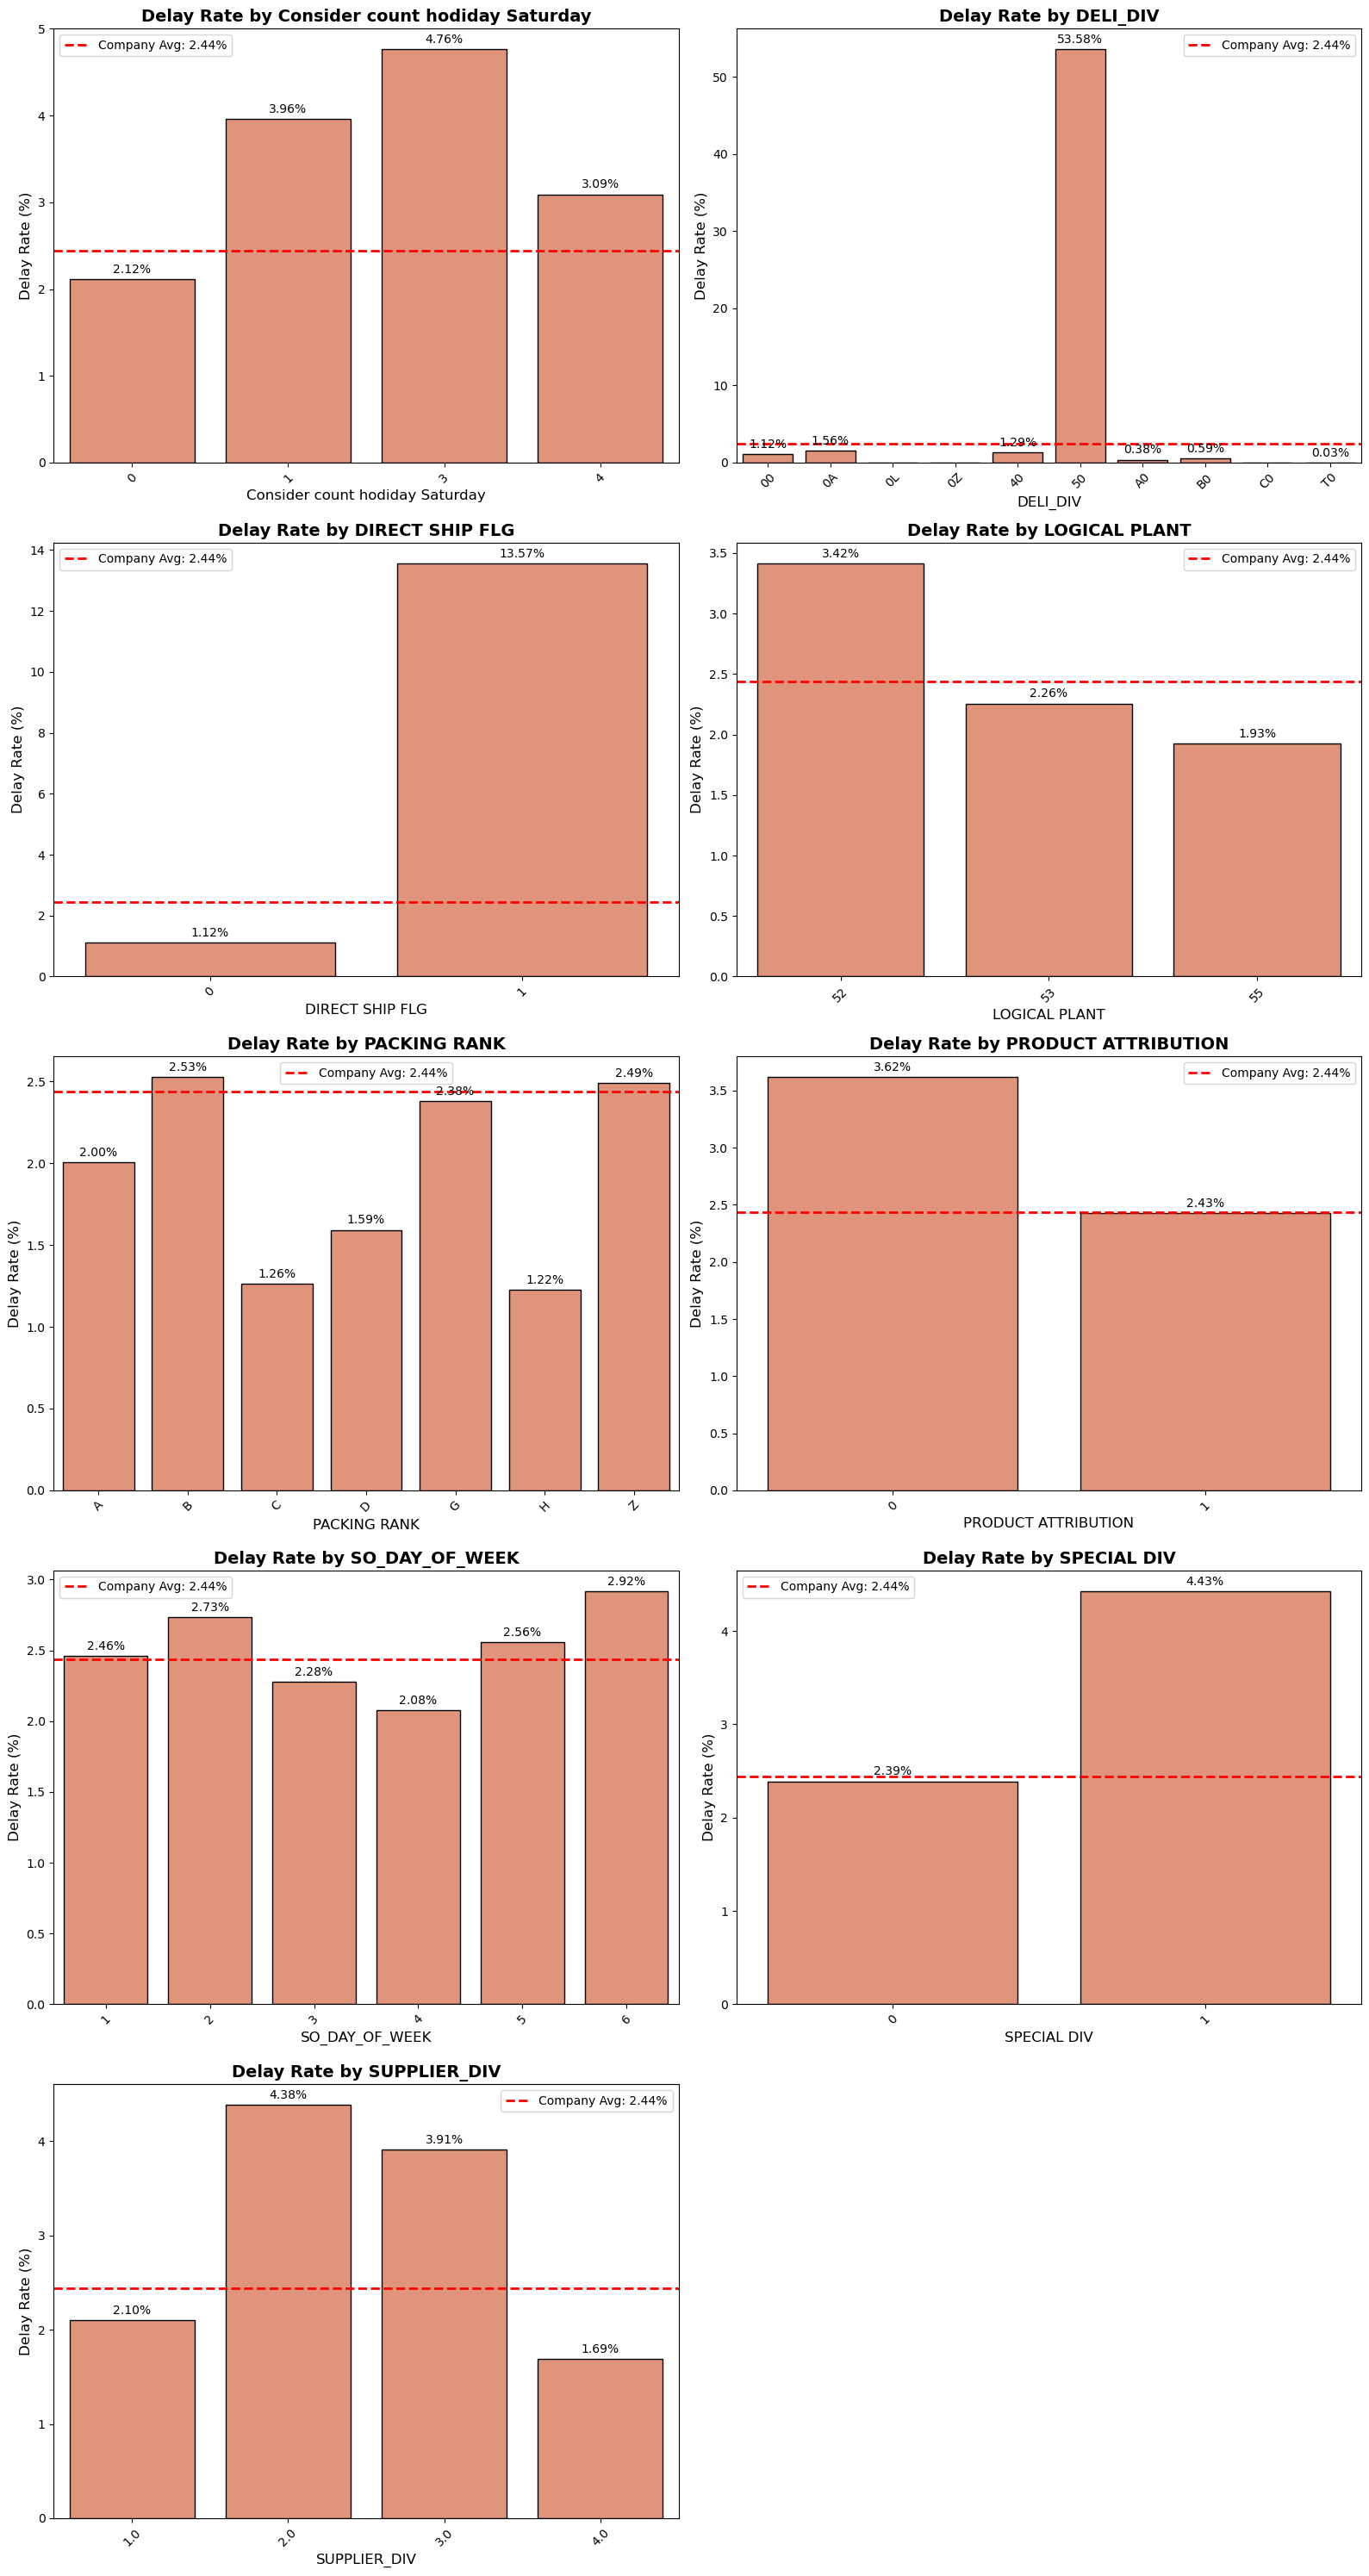

In [45]:
plot_delay_rate(df_7_9, cat_cols_7_9, target_col='label')

Ship Mode
S          232753
P          150381
Q          147484
B          126253
T          124250
C          103488
J           66957
H           42751
V           21465
E           19802
Unknown     14492
R            7949
A            7404
N            5382
Y            1989
F            1746
D             256
Other          95
Name: count, dtype: int64


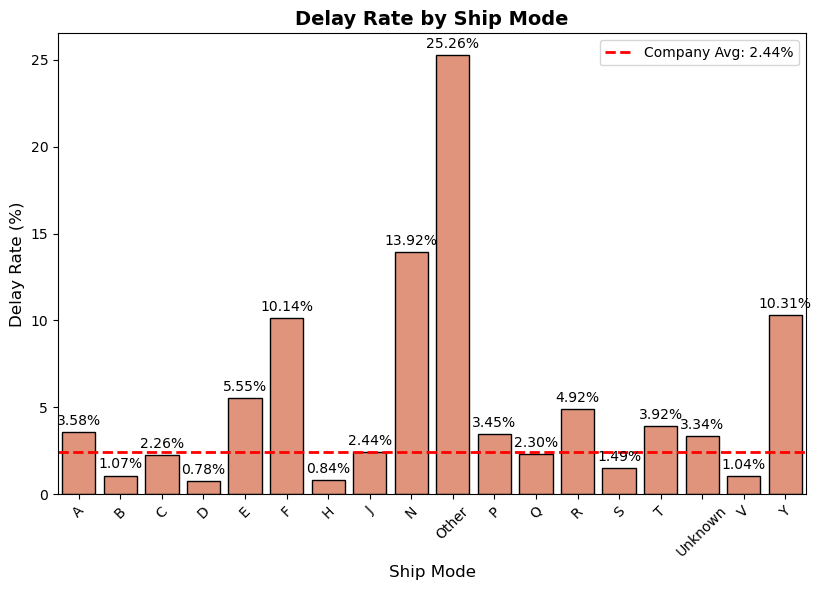

In [46]:
df_7_9['Ship Mode'] = df_7_9['Ship Mode'].fillna('Unknown')


ship_mode_counts = df_7_9['Ship Mode'].value_counts()
rare_modes = ship_mode_counts[ship_mode_counts < 100].index


df_7_9['Ship Mode'] = df_7_9['Ship Mode'].replace(rare_modes, 'Other')

print(df_7_9['Ship Mode'].value_counts())

plot_delay_rate(df_7_9, ['Ship Mode'], target_col='label')

### ANALYZE MULTI-VARIATE FOR DATASET JULY TO SEPTEMBER

Calculating correlation matrix using 'SPEARMAN' method


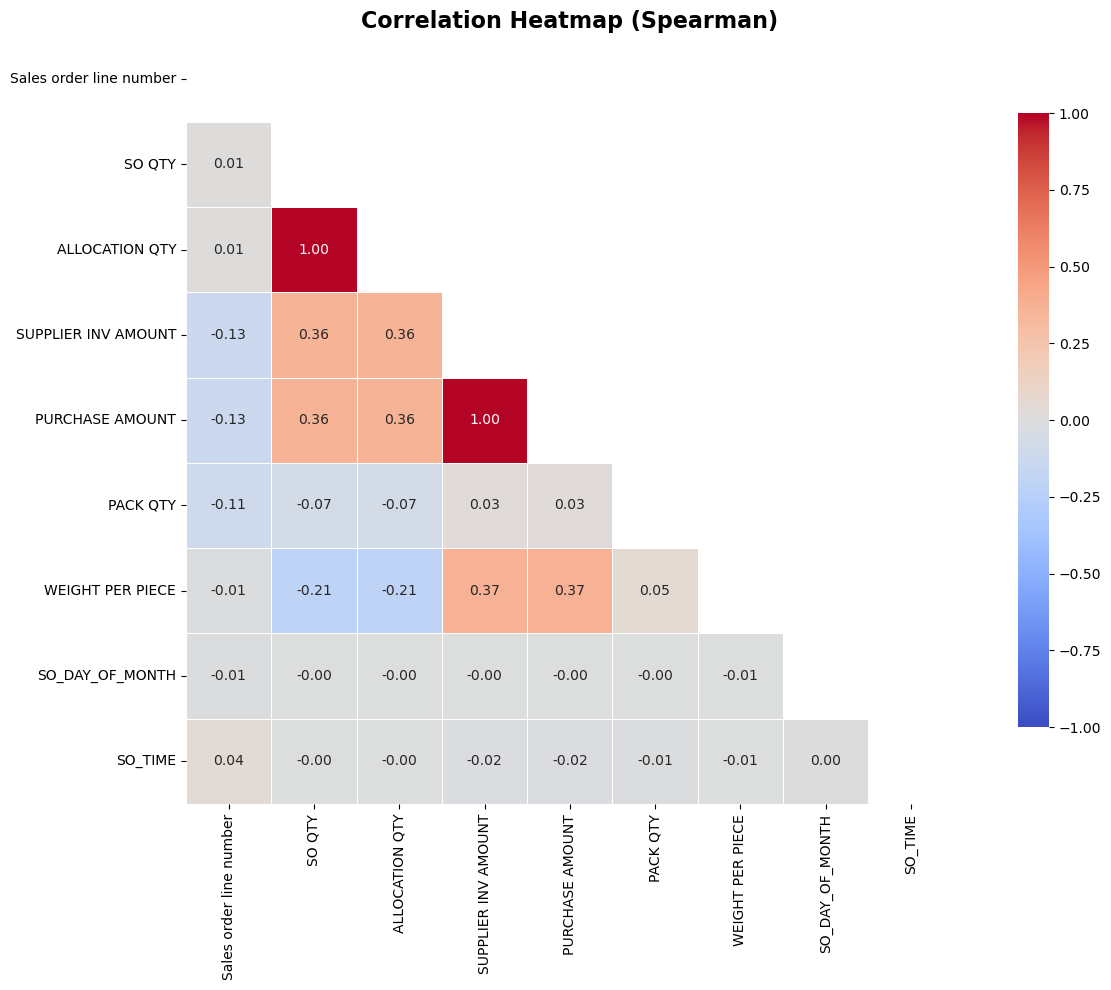

MULTICOLLINEARITY WARNING SYSTEM (Threshold 0.8) 
Feature Pair: [ALLOCATION QTY] and [SO QTY]
Correlation level: 1.00
Recommendation: Consider DROPPING one of these two features

Feature Pair: [PURCHASE AMOUNT] and [SUPPLIER INV AMOUNT]
Correlation level: 1.00
Recommendation: Consider DROPPING one of these two features



In [47]:
plot_correlation_heatmap(df_7_9, num_cols_7_9)

In [51]:
df_7_9.drop(columns=['ALLOCATION QTY', 'SUPPLIER INV AMOUNT'], inplace=True, errors='ignore')
num_cols_7_9 = [col for col in num_cols_7_9 if col not in ['ALLOCATION QTY', 'SUPPLIER INV AMOUNT']]

In [52]:
df_7_9.shape

(1074897, 24)

- Because there are not **SPECIFY_PRODUCTION_DAYS**, **SPECIFY_SHIP_DAYS**, **SUPPLIER_CATEGORY_CD** in dataset JULY TO SEPTEMBER, I will drop them in dataset APRIL TO JUNE

In [54]:
df_4_6.drop(columns=['SPECIFY_PRODUCTION_DAYS', 'SPECIFY_SHIP_DAYS', 'SUPPLIER_CATEGORY_CD'], inplace=True, errors='ignore')
check_columns_name(df_4_6, df_7_9)

They have the same column names


In [56]:
current_dir = Path.cwd()
path_df_4_6 = current_dir / '..' / 'data' / 'tidy' / 'dataset_4_6.csv'
path_df_7_9 = current_dir / '..' / 'data' / 'tidy' / 'dataset_7_9.csv'

if not path_df_4_6.exists():
    export_data(df_4_6, "../data/tidy/dataset_4_6.csv")
else:
    print("This file already exists: ", path_df_4_6)
    
if not path_df_7_9.exists():
    export_data(df_7_9, "../data/tidy/dataset_7_9.csv")
else:
    print("This file already exists: ", path_df_7_9)